#**유통 판매량 예측 및 재고 최적화**
## **단계2 : 모델링을 위한 데이터 전처리**

# **0.미션**

* 단계1 상품별 데이터셋 만들기
    * 가설로 도출된 변수를 반영한 데이터셋을 상품별로 생성
* 단계2 기초 모델 생성
    * base line model : dense layer만 이용해서 기초 모델 생성
    * LSTM, CNN 알고리즘을 이용해서 기초 모델 생성

* 대상 상품(핵심 상품)

| Product_ID|Product_Code|SubCategory|Category|LeadTime|Price|
|----|----|----|----|----|----|
|3|DB001|Beverage|Drink|2|8|
|12|GA001|Milk|Food|3|6|
|42|FM001|Agricultural products|Grocery|3|5|


# **1.환경설정**

* 세부 요구사항
    * 구글콜랩
        * 구글 드라이브 바로 밑에 project 폴더를 만들고,
        * 데이터 파일을 복사해 넣습니다.
    - 라이브러리 로딩
        * 기본적으로 필요한 라이브러리를 import 하도록 코드가 작성되어 있습니다.
        * 필요하다고 판단되는 라이브러리를 추가하세요.


### **(1) 경로 설정**

* 구글 드라이브 연결

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# path = '/content/drive/MyDrive/# KT aivle school/# 수업 코드/#16 Mini Project 6th/'
#path = './'
path = path = 'C:/Users/User/Downloads/2024.11.13_미니프로젝트 6차_1일차 실습자료/'
c_path = '/content/'
figpath = c_path +'figure/'

### **(2) 라이브러리 설치 및 불러오기**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.metrics import *
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

from keras.models import Sequential, Model
from keras.backend import clear_session
from keras.layers import Dense, LSTM, Conv1D, Flatten, Input
from keras.optimizers import Adam

import warnings
warnings.filterwarnings("ignore")

In [7]:
def get_metrics(y_val, y_pred):
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    mape = mean_absolute_percentage_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)

    print('RMSE :', rmse)
    print('MAE :', mae)
    print('MAPE :', mape)
    print('R2 Score :', r2)

    return rmse, mae, mape, r2

In [8]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.plot(history['loss'], label='train_err', marker = '.')
    plt.plot(history['val_loss'], label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

In [9]:
# 예측 결과 시각화
def plot_model_result(y_train, y_val, pred) :

    y_train = pd.Series(y_train)
    y_val = pd.Series(y_val)
    y_val.index = range(len(y_train), len(y_train) + len(y_val))

    pred = pd.Series(pred.reshape(-1,), index = y_val.index)

    # 전체 시각화
    plt.figure(figsize = (20,12))
    plt.subplot(2,1,1)
    plt.plot(y_train, label = 'train')
    plt.plot(y_val, label = 'val')
    plt.plot(pred, label = 'pred')
    plt.legend()
    plt.grid()

    plt.subplot(2,1,2)
    plt.plot(y_val, label = 'val')
    plt.plot(pred, label = 'pred')
    plt.legend()
    plt.grid()

    plt.show()

### **(3) 데이터 불러오기**

In [10]:
oil_price = pd.read_csv(path + '/train/oil_price_train.csv')
orders = pd.read_csv(path + '/train/orders_train.csv')
sales = pd.read_csv(path + '/train/sales_train.csv')
products = pd.read_csv(path + '/train/products.csv')
stores = pd.read_csv(path + '/train/stores.csv')

climate_Arg = pd.read_csv(path + '/climate_Arg.csv')
climate_Bev = pd.read_csv(path + '/climate_Bev.csv')
climate_Milk = pd.read_csv(path + '/climate_Milk.csv')

sales['Date'] = pd.to_datetime(sales['Date'] )
oil_price['Date'] = pd.to_datetime(oil_price['Date'] )
orders['Date'] = pd.to_datetime(orders['Date'] )

# **2.데이터셋 구성하기**

* 세부 요구사항
    * 상품코드 별로 각각 데이터셋을 구성해야 합니다.
    * 도출된 변수들을 포함하는 데이터셋을 구성합니다.


## **(1) 상품 : 3 - Beverage**

In [11]:
store_id = 44
product_id = 3 # product_id 다름
df = sales[(sales['Store_ID']==store_id) & (sales['Product_ID']==product_id)][['Date', 'Qty']]
df = df.set_index('Date')
df['Qty_2day'] = df['Qty'].shift(-2).dropna() # y, target
df.dropna(axis=0, inplace=True)
df.index = pd.to_datetime(df.index)

In [12]:
# Day of week
df['dow'] = df.index.dayofweek
df['dow'] = df['dow'].map({0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'})

# Number of Customer
orders_ = orders.set_index('Date')
df['Num_Customer'] = orders_[orders_['Store_ID']==store_id]['CustomerCount']
df['Num_Customer'].interpolate(method='linear', inplace=True)
df['Num_Customer'].fillna(method='bfill', inplace=True)
df['Num_Customer'] = df['Num_Customer'].astype('int')

In [13]:
# Shift and Diff
steps = [1, 7, 15, 30]
for step in steps:
  daily_sales_change = df['Qty'].diff(step).fillna(0)
  df[f'diff_step{step}'] = daily_sales_change
  daily_sales_change = df['Qty'].shift(step).fillna(0)
  df[f'shift_step{step}'] = daily_sales_change

# Climate Data
df2 = climate_Bev.set_index('Date') # 상품마다 파일이 다르므로 파이프라인 만들떄 조심!!
df2.index = pd.to_datetime(df2.index)
df[df2.columns[:-1]] = df2[df2.columns[:-1]]
df = df.interpolate(method='linear')

In [18]:
# Same Category
prod_target = products[products['Category']=='Drink'] # 각 상품별로 바꿔야돼요. Milk -> food, Agricular
id_list = prod_target['Product_ID'].tolist()
names = prod_target['SubCategory'].tolist()
temp = sales[(sales['Store_ID']==44) & (sales['Product_ID'].isin(id_list))][['Date', 'Qty', 'Product_ID']]
df2 = temp.groupby(['Date', 'Product_ID']).sum().reset_index()
df2 = df2.pivot(index='Date', columns='Product_ID', values='Qty')
df2.columns = names
df['Wine'] = df2['Wine'] # 각 카테별로 동일한 상품들

# Oil Price
oil_price_ = oil_price.copy()
oil_price_ = oil_price_.set_index('Date')
df['WTI_Price'] = oil_price_['WTI_Price']
df['WTI_Price'] = df['WTI_Price'].interpolate(method='linear')
df['WTI_Price'].iloc[0] = df['WTI_Price'].iloc[1]
data_Bev = df.copy() #여기도 바꿔야함
data_Bev.head()

,Qty,Qty_2day,dow,Num_Customer,diff_step1,shift_step1,diff_step7,shift_step7,diff_step15,shift_step15,...,shift_step30,Max Temp,Min Temp,Precipitation (inches),accum30.Prec.,accum60.Prec.,accum90.Prec.,accum120.Prec.,Wine,WTI_Price
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-01,0.0,8647.0,Wed,4422,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-8.0,0.000000,1.990000,2.630000,4.865000,7.235000,0.0,95.14
2014-01-02,9853.0,15153.0,Thu,4422,9853.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,-10.0,0.000000,1.910000,2.630000,4.575000,7.235000,9853.0,95.14
2014-01-03,8647.0,15606.0,Fri,4167,-1206.0,9853.0,0.0,0.0,0.0,0.0,...,0.0,29.0,-10.0,0.120000,1.510000,2.580000,4.685000,7.355000,8647.0,93.66
2014-01-04,15153.0,7900.0,Sat,5341,6506.0,8647.0,0.0,0.0,0.0,0.0,...,0.0,35.0,-2.0,0.020000,1.270000,2.420000,4.655000,7.375000,15153.0,93.48
2014-01-05,15606.0,7188.0,Sun,5123,453.0,15153.0,0.0,0.0,0.0,0.0,...,0.0,-2.0,-20.0,0.013333,1.283333,2.383333,4.668333,7.388333,15606.0,93.30


## **(2) 상품 : 12 - Milk**

In [24]:
store_id = 44
product_id = 12
df = sales[(sales['Store_ID']==store_id) & (sales['Product_ID']==product_id)][['Date', 'Qty']]
df = df.set_index('Date')
df['Qty_1day'] = df['Qty'].shift(-1).dropna()
df['Qty_2day'] = df['Qty'].shift(-2).dropna()
df.dropna(axis=0, inplace=True)
df.index = pd.to_datetime(df.index)

In [26]:
# Day of week
df['dow'] = df.index.dayofweek
df['dow'] = df['dow'].map({0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'})

# Number of Customer
orders_ = orders.set_index('Date')
df['Num_Customer'] = orders_[orders_['Store_ID']==store_id]['CustomerCount']
df['Num_Customer'].interpolate(method='linear', inplace=True)
df['Num_Customer'].fillna(method='bfill', inplace=True)
df['Num_Customer'] = df['Num_Customer'].astype('int')

In [28]:
# Shift and Diff
steps = [1, 7, 15, 30]
for step in steps:
  daily_sales_change = df['Qty'].diff(step).fillna(0)
  df[f'diff_step{step}'] = daily_sales_change
  daily_sales_change = df['Qty'].shift(step).fillna(0)
  df[f'shift_step{step}'] = daily_sales_change

# Climate Data
df2 = climate_Bev.set_index('Date') # 상품마다 파일이 다르므로 파이프라인 만들떄 조심!!
df2.index = pd.to_datetime(df2.index)
df[df2.columns] = df2
df = df.interpolate(method='linear')
data_Milk = df.copy()

In [30]:
# Same Category
prod_target = products[products['Category']=='Food'] # 각 상품별로 바꿔야돼요. Milk -> food, Agricular
id_list = prod_target['Product_ID'].tolist()
names = prod_target['SubCategory'].tolist()
temp = sales[(sales['Store_ID']==44) & (sales['Product_ID'].isin(id_list))][['Date', 'Qty', 'Product_ID']]
df2 = temp.groupby(['Date', 'Product_ID']).sum().reset_index()
df2 = df2.pivot(index='Date', columns='Product_ID', values='Qty')
df2.columns = names
df['Yogurt'] = df2['Yogurt'] # 각 카테별로 동일한 상품들
df['BAKERY'] = df2['BAKERY'] # 각 카테별로 동일한 상품들
df['Frozen'] = df2['Frozen'] # 각 카테별로 동일한 상품들
df['Prepared'] = df2['Prepared'] # 각 카테별로 동일한 상품들

# Oil Price
oil_price_ = oil_price.copy()
oil_price_ = oil_price_.set_index('Date')
df['WTI_Price'] = oil_price_['WTI_Price']
df['WTI_Price'] = df['WTI_Price'].interpolate(method='linear')
df['WTI_Price'].iloc[0] = df['WTI_Price'].iloc[1]
data_Milk = df.copy() #여기도 바꿔야함
data_Milk.head()

,Qty,Qty_1day,Qty_2day,dow,Num_Customer,diff_step1,shift_step1,diff_step7,shift_step7,diff_step15,...,accum30.Prec.,accum60.Prec.,accum90.Prec.,accum120.Prec.,Beverage_Qty,Yogurt,BAKERY,Frozen,Prepared,WTI_Price
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-01,0.0,9647.0,8879.0,Wed,4422,0.0,0.0,0.0,0.0,0.0,...,1.990000,2.630000,4.865000,7.235000,8523.096774,0.0,0.000,0.0,0.000,95.14
2014-01-02,9647.0,8879.0,14188.0,Thu,4422,9647.0,0.0,0.0,0.0,0.0,...,1.910000,2.630000,4.575000,7.235000,9853.000000,9647.0,600.931,2991.0,1302.470,95.14
2014-01-03,8879.0,14188.0,14490.0,Fri,4167,-768.0,9647.0,0.0,0.0,0.0,...,1.510000,2.580000,4.685000,7.355000,8647.000000,8879.0,621.938,2694.0,1243.054,93.66
2014-01-04,14188.0,14490.0,7614.0,Sat,5341,5309.0,8879.0,0.0,0.0,0.0,...,1.270000,2.420000,4.655000,7.375000,15153.000000,14188.0,883.348,4355.0,1882.780,93.48
2014-01-05,14490.0,7614.0,7124.0,Sun,5123,302.0,14188.0,0.0,0.0,0.0,...,1.283333,2.383333,4.668333,7.388333,15606.000000,14490.0,854.104,4228.0,2029.317,93.30


## **(3) 상품 : 42 - Agricultural products**

In [32]:
# 기본 데이터 셋 불러오기
store_id = 44
product_id = 42
df = sales[(sales['Store_ID']==store_id) & (sales['Product_ID']==product_id)][['Date', 'Qty']]
df = df.set_index('Date')
df['Qty_1day'] = df['Qty'].shift(-1).dropna()
df['Qty_2day'] = df['Qty'].shift(-2).dropna()
df.dropna(axis=0, inplace=True)
df.index = pd.to_datetime(df.index)

In [34]:
# Day of week
df['dow'] = df.index.dayofweek
df['dow'] = df['dow'].map({0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'})

# Number of Customer
orders_ = orders.set_index('Date')
df['Num_Customer'] = orders_[orders_['Store_ID']==store_id]['CustomerCount']
df['Num_Customer'].interpolate(method='linear', inplace=True)
df['Num_Customer'].fillna(method='bfill', inplace=True)
df['Num_Customer'] = df['Num_Customer'].astype('int')

In [36]:
# Shift and Diff
steps = [1, 7, 15, 30]
for step in steps:
  daily_sales_change = df['Qty'].diff(step).fillna(0)
  df[f'diff_step{step}'] = daily_sales_change
  daily_sales_change = df['Qty'].shift(step).fillna(0)
  df[f'shift_step{step}'] = daily_sales_change

# Climate Data
df2 = climate_Arg.set_index('Date')
df2.index = pd.to_datetime(df2.index)
df[['Max Temp', 'Min Temp', 'accum90.Prec.']] = df2[['Max Temp', 'Min Temp', 'accum90.Prec.']]
data_Agr = df.copy()

In [38]:
# Same Category
prod_target = products[products['Category']=='Grocery'] # 각 상품별로 바꿔야돼요. Milk -> food, Agricular
id_list = prod_target['Product_ID'].tolist()
names = prod_target['SubCategory'].tolist()
temp = sales[(sales['Store_ID']==44) & (sales['Product_ID'].isin(id_list))][['Date', 'Qty', 'Product_ID']]
df2 = temp.groupby(['Date', 'Product_ID']).sum().reset_index()
df2 = df2.pivot(index='Date', columns='Product_ID', values='Qty')
df2.columns = names
df['Seafood'] = df2['Seafood'] # 각 카테별로 동일한 상품들
df['EGGS'] = df2['EGGS'] # 각 카테별로 동일한 상품들
df['Meats'] = df2['Meats'] # 각 카테별로 동일한 상품들

# Oil Price
oil_price_ = oil_price.copy()
oil_price_ = oil_price_.set_index('Date')
df['WTI_Price'] = oil_price_['WTI_Price']
df['WTI_Price'] = df['WTI_Price'].interpolate(method='linear')
df['WTI_Price'].iloc[0] = df['WTI_Price'].iloc[1]
data_Agr = df.copy() #여기도 바꿔야함
data_Agr.head()

,Qty,Qty_1day,Qty_2day,dow,Num_Customer,diff_step1,shift_step1,diff_step7,shift_step7,diff_step15,shift_step15,diff_step30,shift_step30,Max Temp,Min Temp,accum90.Prec.,Seafood,EGGS,Meats,WTI_Price
Date,,,,,,,,,,,,,,,,,,,,
2014-01-01,51.0,76.0,74.0,Wed,4422,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-8.0,4.865000,0.0,0.0000,0.0000,95.14
2014-01-02,76.0,74.0,78.0,Thu,4422,25.0,51.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,-10.0,4.575000,780.0,981.6440,124.9780,95.14
2014-01-03,74.0,78.0,88.0,Fri,4167,-2.0,76.0,0.0,0.0,0.0,0.0,0.0,0.0,29.0,-10.0,4.685000,677.0,1278.9081,115.0889,93.66
2014-01-04,78.0,88.0,65.0,Sat,5341,4.0,74.0,0.0,0.0,0.0,0.0,0.0,0.0,35.0,-2.0,4.655000,1126.0,1398.6660,171.1640,93.48
2014-01-05,88.0,65.0,78.0,Sun,5123,10.0,78.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.0,-20.0,4.668333,1118.0,1119.5350,217.2520,93.30


# **3.Baseline Model**

* **세부 요구사항**
    * 데이터 준비
        * 스케일링
            * 교과서 적으로는 데이터 분할 이후 스케일링하는게 맞지만, 데이터 건수가 충분히 크다면, 스케일링을 먼저 하기도 합니다.
            * 여기서는 먼저 스케일링을 한 후 데이터 분할을 합니다.
        * 데이터 분할
            * 검증셋 구성 : 학습용 데이터에서 최근 60일을 검증셋으로 사용.

    * 모델링
        * Dense Layer 1개(output layer)만으로 모델을 생성합니다.
        * 모델의 검증 성능을 평가하고 기록합니다.
        * 평가 지표 : RMSE, MAE, MAPE, R2 Score


## **(1) 상품 : 3 - Beverage**

### **1) 데이터 준비**

In [47]:
data_Bev = pd.get_dummies(data_Bev, columns = ['dow'], drop_first = True)

In [49]:
data_Bev

,Qty,Qty_2day,Num_Customer,diff_step1,shift_step1,diff_step7,shift_step7,diff_step15,shift_step15,diff_step30,...,accum90.Prec.,accum120.Prec.,Wine,WTI_Price,dow_Mon,dow_Sat,dow_Sun,dow_Thu,dow_Tue,dow_Wed
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-01,0.0,8647.0,4422,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.865000,7.235000,0.0,95.14,False,False,False,False,False,True
2014-01-02,9853.0,15153.0,4422,9853.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.575000,7.235000,9853.0,95.14,False,False,False,True,False,False
2014-01-03,8647.0,15606.0,4167,-1206.0,9853.0,0.0,0.0,0.0,0.0,0.0,...,4.685000,7.355000,8647.0,93.66,False,False,False,False,False,False
2014-01-04,15153.0,7900.0,5341,6506.0,8647.0,0.0,0.0,0.0,0.0,0.0,...,4.655000,7.375000,15153.0,93.48,False,True,False,False,False,False
2014-01-05,15606.0,7188.0,5123,453.0,15153.0,0.0,0.0,0.0,0.0,0.0,...,4.668333,7.388333,15606.0,93.30,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-02-22,7856.0,10208.0,3834,679.0,7177.0,2.0,7854.0,-368.0,8224.0,-2301.0,...,11.200000,14.620000,7856.0,53.61,False,False,False,False,False,True
2017-02-23,8018.0,12361.0,3955,162.0,7856.0,189.0,7829.0,-2260.0,10278.0,-642.0,...,11.200000,14.620000,8018.0,54.48,False,False,False,True,False,False
2017-02-24,10208.0,10108.0,4549,2190.0,8018.0,684.0,9524.0,2391.0,7817.0,1743.0,...,11.200000,14.620000,10208.0,53.99,False,False,False,False,False,False


In [51]:
sc = MinMaxScaler()
sc_y = MinMaxScaler()

x1 = data_Bev.drop(columns = 'Qty_2day')
y1 = data_Bev['Qty_2day']

x1_train, x1_val = x1.iloc[:-60], x1.iloc[-60:]
y1_train, y1_val = y1.iloc[:-60], y1.iloc[-60:]

In [53]:
data_Bev

,Qty,Qty_2day,Num_Customer,diff_step1,shift_step1,diff_step7,shift_step7,diff_step15,shift_step15,diff_step30,...,accum90.Prec.,accum120.Prec.,Wine,WTI_Price,dow_Mon,dow_Sat,dow_Sun,dow_Thu,dow_Tue,dow_Wed
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-01,0.0,8647.0,4422,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.865000,7.235000,0.0,95.14,False,False,False,False,False,True
2014-01-02,9853.0,15153.0,4422,9853.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.575000,7.235000,9853.0,95.14,False,False,False,True,False,False
2014-01-03,8647.0,15606.0,4167,-1206.0,9853.0,0.0,0.0,0.0,0.0,0.0,...,4.685000,7.355000,8647.0,93.66,False,False,False,False,False,False
2014-01-04,15153.0,7900.0,5341,6506.0,8647.0,0.0,0.0,0.0,0.0,0.0,...,4.655000,7.375000,15153.0,93.48,False,True,False,False,False,False
2014-01-05,15606.0,7188.0,5123,453.0,15153.0,0.0,0.0,0.0,0.0,0.0,...,4.668333,7.388333,15606.0,93.30,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-02-22,7856.0,10208.0,3834,679.0,7177.0,2.0,7854.0,-368.0,8224.0,-2301.0,...,11.200000,14.620000,7856.0,53.61,False,False,False,False,False,True
2017-02-23,8018.0,12361.0,3955,162.0,7856.0,189.0,7829.0,-2260.0,10278.0,-642.0,...,11.200000,14.620000,8018.0,54.48,False,False,False,True,False,False
2017-02-24,10208.0,10108.0,4549,2190.0,8018.0,684.0,9524.0,2391.0,7817.0,1743.0,...,11.200000,14.620000,10208.0,53.99,False,False,False,False,False,False


In [55]:
x1_train = sc.fit_transform(x1_train)
x1_val = sc.transform(x1_val)

y1_train_scaled = sc_y.fit_transform(y1_train.values.reshape(-1,1)).ravel()
y1_val_scaled = sc_y.transform(y1_val.values.reshape(-1,1)).ravel()

### **2) 모델링**

In [444]:
clear_session()

n_feature = x1_train.shape[1]

In [445]:
n_feature

25

In [446]:
model = Sequential()
model.add(Dense(1, input_shape=(n_feature,)))
model.summary()
model.compile(loss = 'mse', optimizer = Adam())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 26 (104.00 B)

 Trainable params: 26 (104.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.2027 - val_loss: 0.1018
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1039 - val_loss: 0.0760
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0831 - val_loss: 0.0599
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0652 - val_loss: 0.0473
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0484 - val_loss: 0.0380
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0405 - val_loss: 0.0318
Epoch 7/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0311 - val_loss: 0.0282
Epoch 8/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0289 - val_loss: 0.0247
Epoch 9/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0252 - val_loss: 0.0226
Epoch 10/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0211 - val_loss: 0.0213
Epoch 11/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0201 - val_loss: 0.0205
Epoch 12/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.

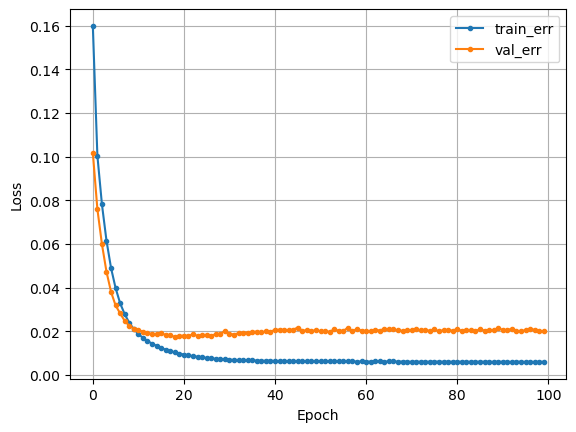

In [448]:
history = model.fit(x1_train, y1_train_scaled, epochs=100, batch_size=16, validation_data=(x1_val, y1_val_scaled))
dl_history_plot(history.history)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
RMSE : 3604.3264069542947
MAE : 2379.711389160156
MAPE : 1.154207273504368e+18
R2 Score : 0.17582830302072072


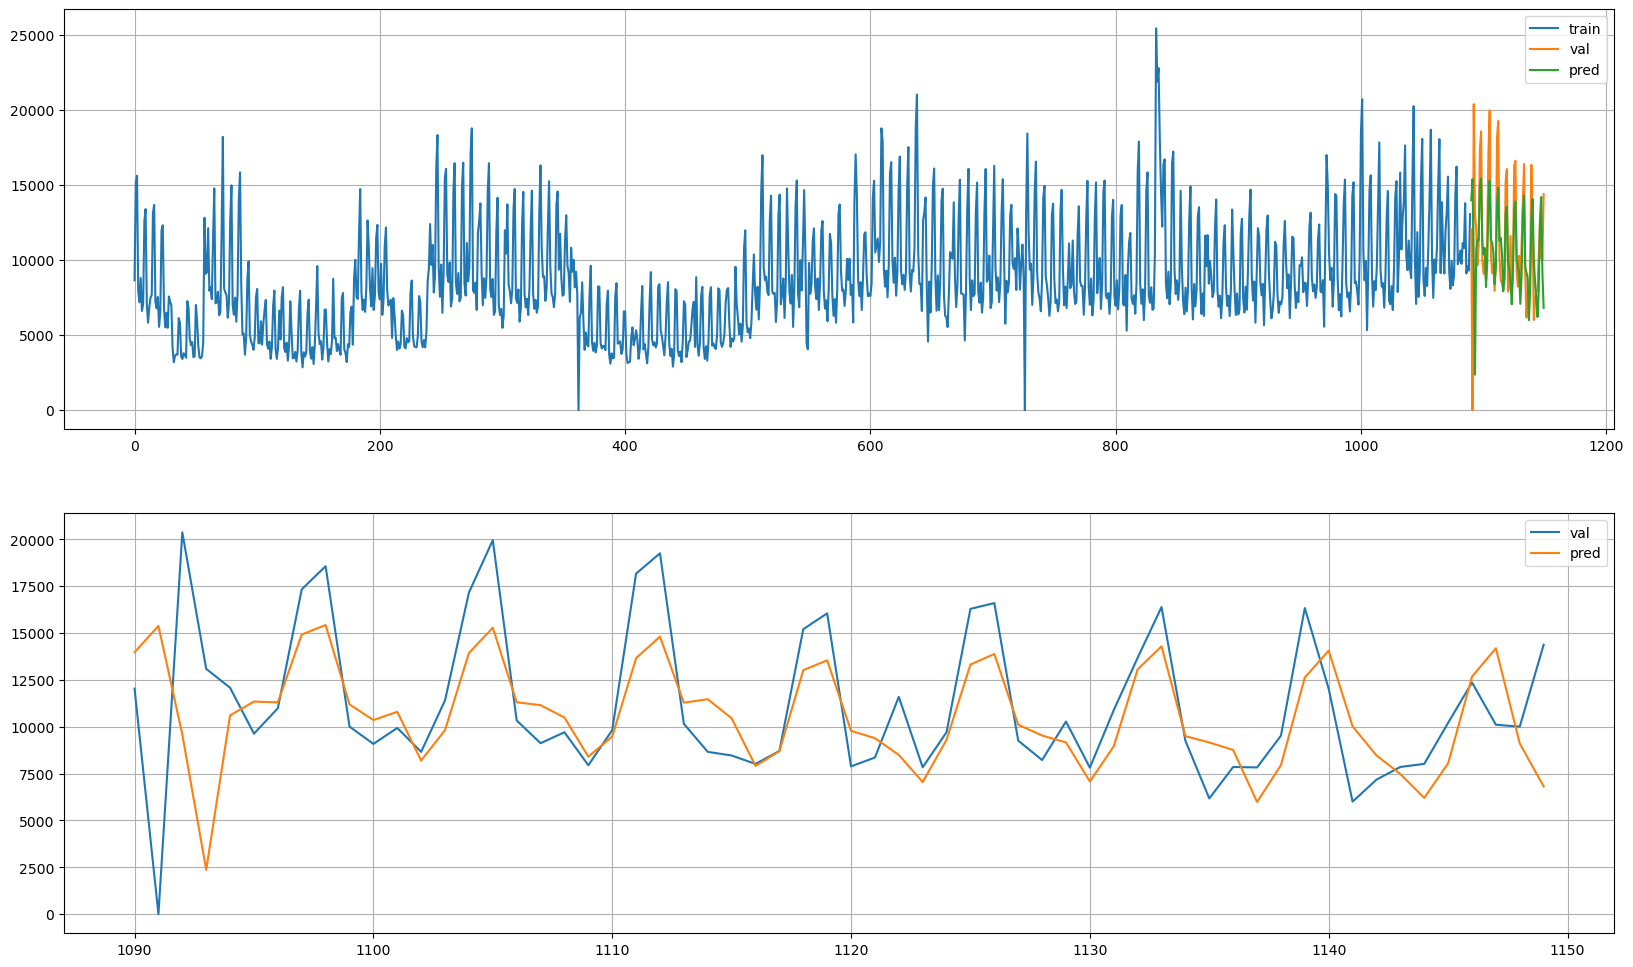

In [451]:
y_pred_1 = model.predict(x1_val)
y_pred = sc_y.inverse_transform(y_pred_1)

get_metrics(y1_val, y_pred)
plot_model_result(y1_train.values, y1_val, y_pred)

## **(2) 상품 : 12 - Milk**

### **1) 데이터 준비**

In [58]:
data_Milk = pd.get_dummies(data_Milk, columns = ['dow'], drop_first = True)

In [60]:
sc = MinMaxScaler()
sc_y = MinMaxScaler()

x2 = data_Milk.drop(columns = 'Qty_2day')
y2 = data_Milk['Qty_2day']

x2_train, x2_val = x2.iloc[:-60], x2.iloc[-60:]
y2_train, y2_val = y2.iloc[:-60], y2.iloc[-60:]

In [62]:
x2_train = sc.fit_transform(x2_train)
x2_val = sc.transform(x2_val)

y2_train_scaled = sc_y.fit_transform(y2_train.values.reshape(-1,1)).ravel()
y2_val_scaled = sc_y.transform(y2_val.values.reshape(-1,1)).ravel()

### **2) 모델링**

In [463]:
clear_session()

n_feature = x2_train.shape[1]

model = Sequential()
model.add(Dense(1, input_shape=(n_feature,)))
model.summary()
model.compile(loss = 'mse', optimizer = Adam())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 26 (104.00 B)

 Trainable params: 26 (104.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.7219 - val_loss: 0.2340
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2272 - val_loss: 0.1021
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1015 - val_loss: 0.0809
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0814 - val_loss: 0.0680
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0663 - val_loss: 0.0571
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0526 - val_loss: 0.0482
Epoch 7/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0415 - val_loss: 0.0415
Epoch 8/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0316 - val_loss: 0.0358
Epoch 9/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0261 - val_loss: 0.0316
Epoch 10/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0237 - val_loss: 0.0283
Epoch 11/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0181 - val_loss: 0.0260
Epoch 12/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.

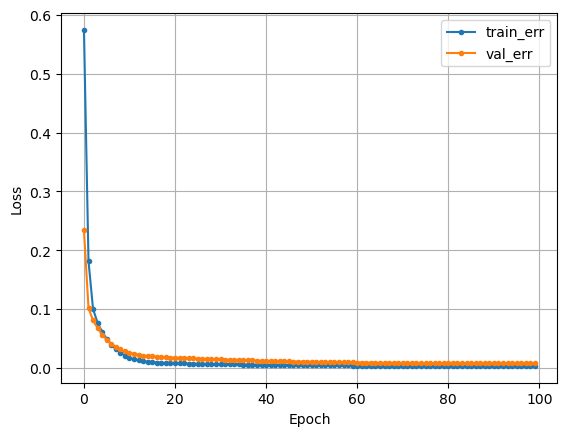

In [464]:
history = model.fit(x2_train, y2_train_scaled, epochs=100, batch_size=16, validation_data=(x2_val, y2_val_scaled))
dl_history_plot(history.history)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
RMSE : 3298.658804403309
MAE : 1824.1008626302084
MAPE : 1.0840627563979954e+18
R2 Score : 0.11454854179327312


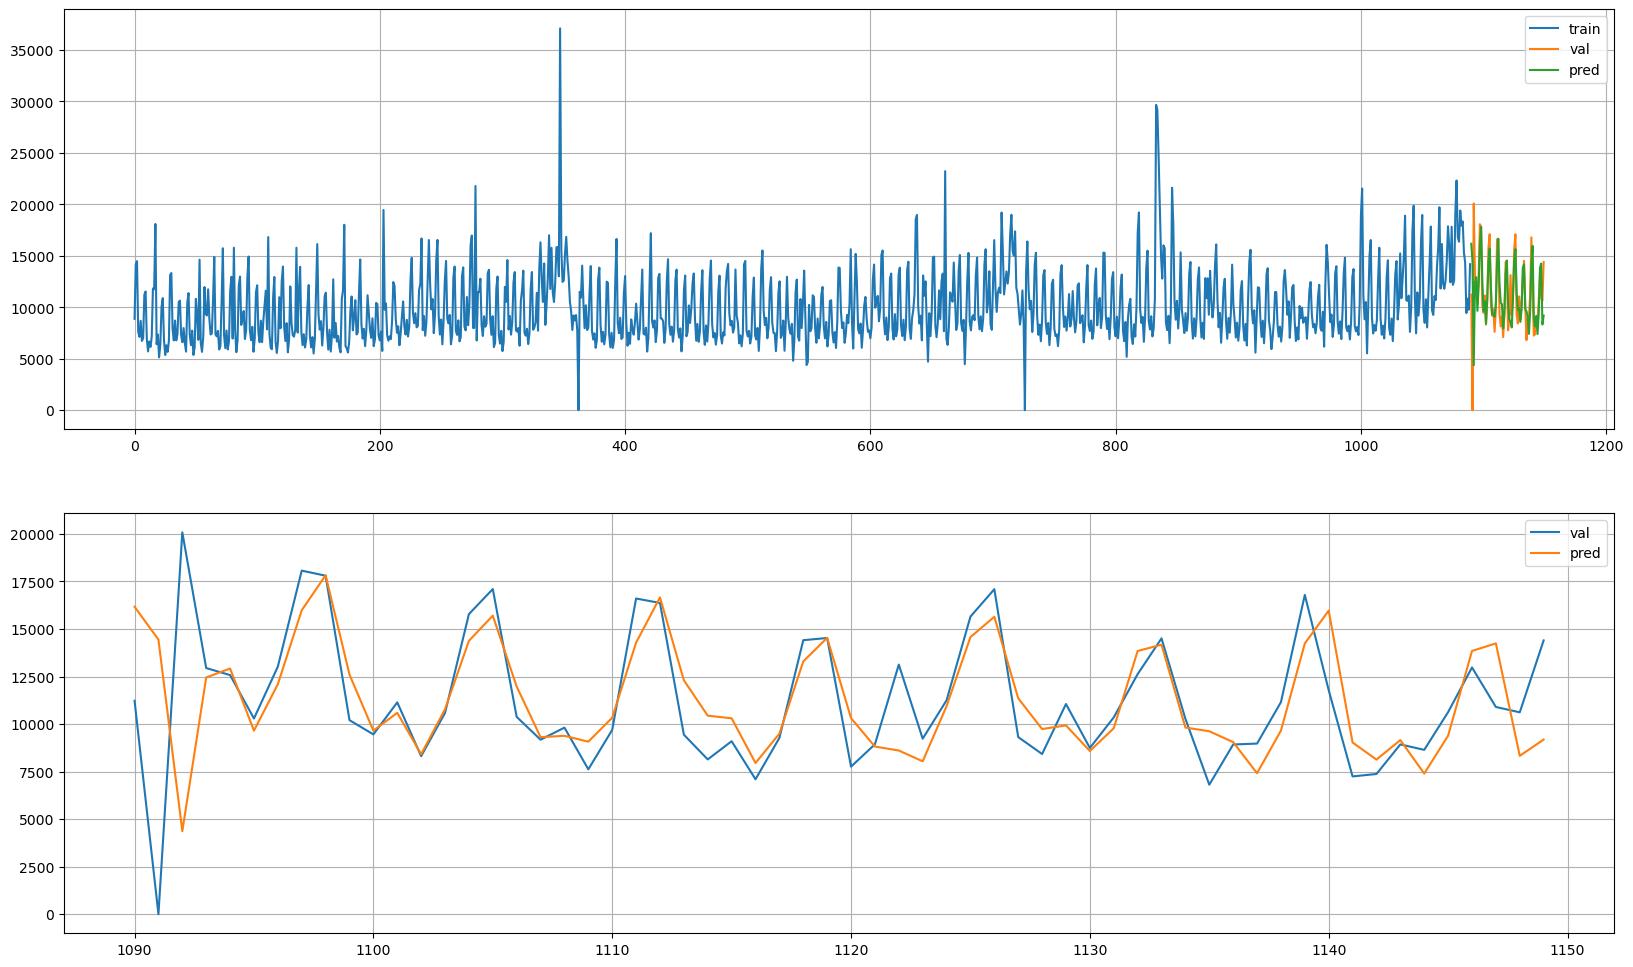

In [465]:
y_pred_2 = model.predict(x2_val)
y_pred = sc_y.inverse_transform(y_pred_2)

get_metrics(y2_val, y_pred)
plot_model_result(y2_train.values, y2_val, y_pred)

## **(3) 상품 : 42 - Agricultural products**

### **1) 데이터 준비**

In [65]:
data_Agr = pd.get_dummies(data_Agr, columns = ['dow'], drop_first = True)

In [67]:
sc = MinMaxScaler()
sc_y = MinMaxScaler()

x3 = data_Agr.drop(columns = 'Qty_2day')
y3 = data_Agr['Qty_2day']

x3_train, x3_val = x3.iloc[:-60], x3.iloc[-60:]
y3_train, y3_val = y3.iloc[:-60], y3.iloc[-60:]

In [69]:
x3_train = sc.fit_transform(x3_train)
x3_val = sc.transform(x3_val)

y3_train_scaled = sc_y.fit_transform(y3_train.values.reshape(-1,1)).ravel()
y3_val_scaled = sc_y.transform(y3_val.values.reshape(-1,1)).ravel()

### **2) 모델링**

In [472]:
clear_session()

n_feature = x3_train.shape[1]

model = Sequential()
model.add(Dense(1, input_shape=(n_feature,)))
model.summary()
model.compile(loss = 'mse', optimizer = Adam())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21 (84.00 B)

 Trainable params: 21 (84.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2881 - val_loss: 0.0502
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0779 - val_loss: 0.0577
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0605 - val_loss: 0.0521
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0506 - val_loss: 0.0426
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0410 - val_loss: 0.0370
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0346 - val_loss: 0.0329
Epoch 7/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0293 - val_loss: 0.0296
Epoch 8/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0250 - val_loss: 0.0260
Epoch 9/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0219 - val_loss: 0.0231
Epoch 10/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0179 - val_loss: 0.0208
Epoch 11/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0167 - val_loss: 0.0192
Epoch 12/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.

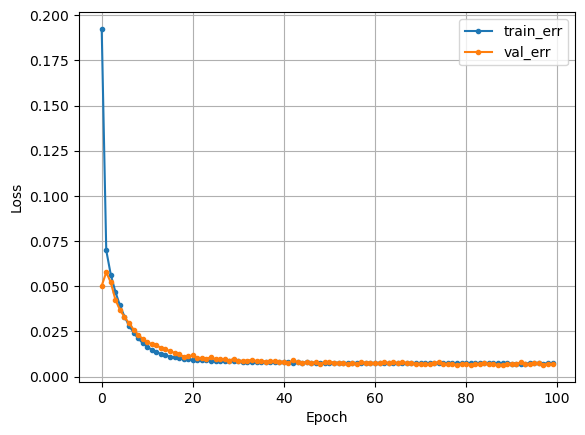

In [473]:
history = model.fit(x3_train, y3_train_scaled, epochs=100, batch_size=16, validation_data=(x3_val, y3_val_scaled))
dl_history_plot(history.history)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
RMSE : 12.507786223404437
MAE : 9.95184783935547
MAPE : 0.11542939410239016
R2 Score : 0.31981461797320443


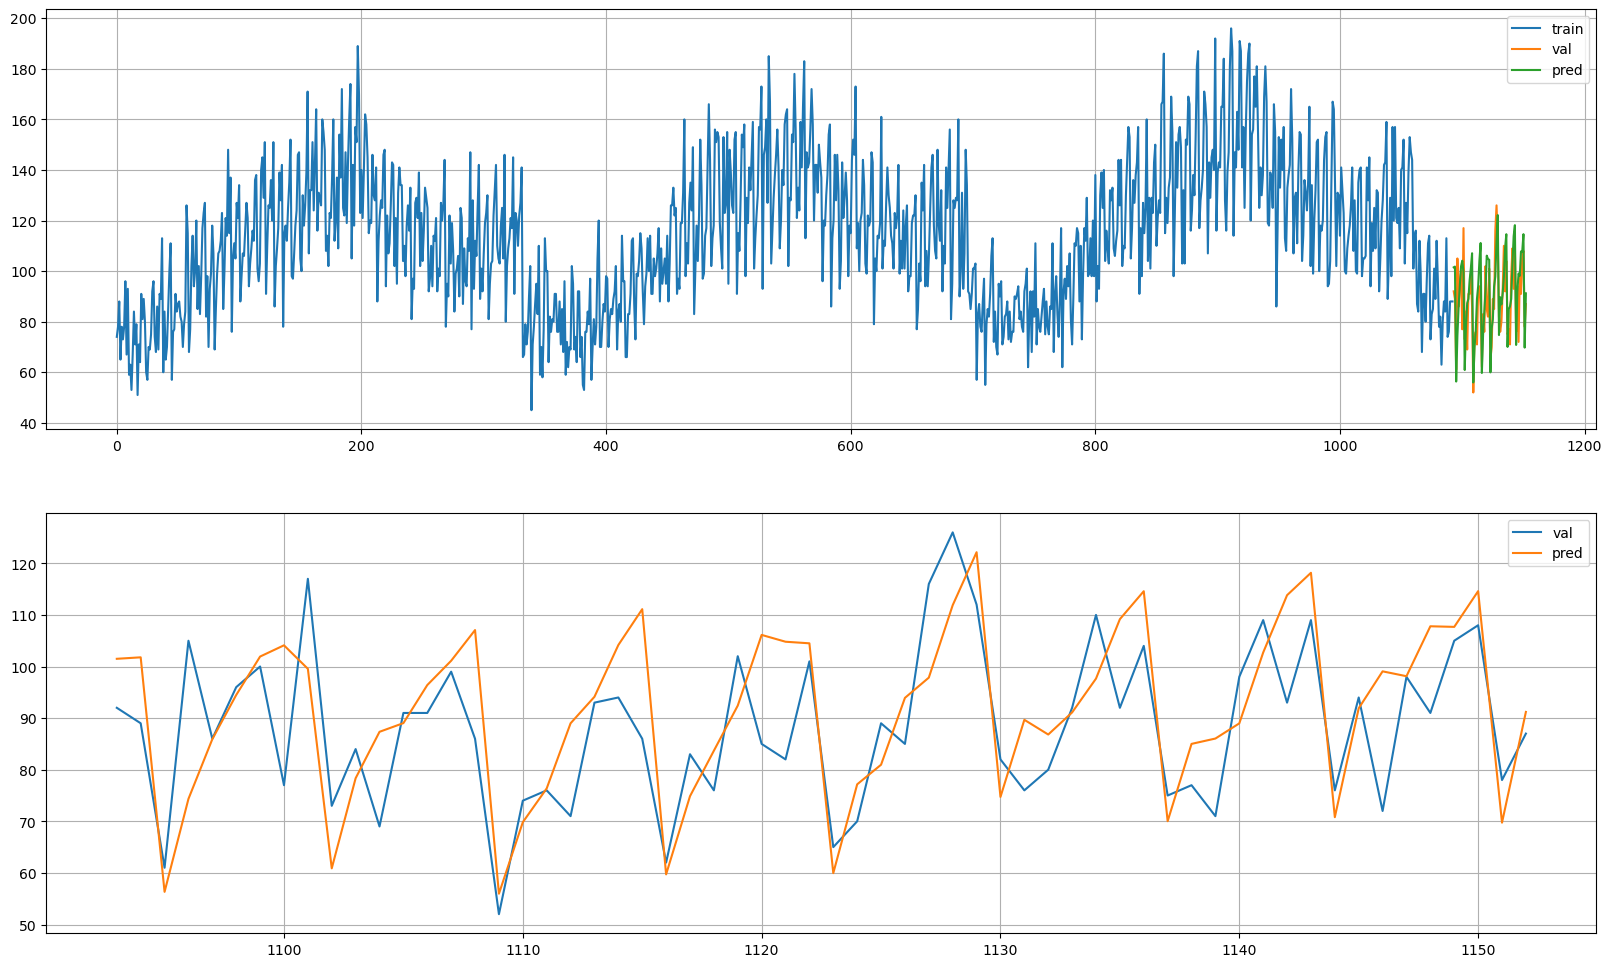

In [474]:
y_pred_3 = model.predict(x3_val)
y_pred = sc_y.inverse_transform(y_pred_3)

get_metrics(y3_val, y_pred)
plot_model_result(y3_train.values, y3_val, y_pred)

# **4.LSTM, CNN 초기 모델**

* **세부 요구사항**
    * 3차원 데이터 구조 만들기
        * timestep 수는 적절한 간격으로 한가지 경우만 지정을 합니다.
    * LSTM, CNN 기반 초기 모델 생성
        * 성능 보다는 코드 틀을 작성하는데 집중합시다.
        * 노드 혹은 필터 수와 크기는 초기값으로 적절하게 지정해 봅시다.

## **(2) 상품 : 12 - Milk**

In [489]:
store_id = 44
product_id = 12
df = sales[(sales['Store_ID']==store_id) & (sales['Product_ID']==product_id)][['Date', 'Qty']]
df = df.set_index('Date')
df['Qty_1day'] = df['Qty'].shift(-1).dropna()
df['Qty_2day'] = df['Qty'].shift(-2).dropna()
df.dropna(axis=0, inplace=True)
df.index = pd.to_datetime(df.index)

In [491]:
# Day of week
df['dow'] = df.index.dayofweek
df['dow'] = df['dow'].map({0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'})

# Number of Customer
orders_ = orders.set_index('Date')
df['Num_Customer'] = orders_[orders_['Store_ID']==store_id]['CustomerCount']
df['Num_Customer'].interpolate(method='linear', inplace=True)
df['Num_Customer'].fillna(method='bfill', inplace=True)
df['Num_Customer'] = df['Num_Customer'].astype('int')

In [492]:
# Shift and Diff
steps = [1, 7, 15, 30]
for step in steps:
  daily_sales_change = df['Qty'].diff(step).fillna(0)
  df[f'diff_step{step}'] = daily_sales_change
  daily_sales_change = df['Qty'].shift(step).fillna(0)
  df[f'shift_step{step}'] = daily_sales_change

# Climate Data
df2 = climate_Bev.set_index('Date') # 상품마다 파일이 다르므로 파이프라인 만들떄 조심!!
df2.index = pd.to_datetime(df2.index)
df[df2.columns] = df2
df = df.interpolate(method='linear')
data_Milk = df.copy()

In [493]:
# Same Category
prod_target = products[products['Category']=='Food'] # 각 상품별로 바꿔야돼요. Milk -> food, Agricular
id_list = prod_target['Product_ID'].tolist()
names = prod_target['SubCategory'].tolist()
temp = sales[(sales['Store_ID']==44) & (sales['Product_ID'].isin(id_list))][['Date', 'Qty', 'Product_ID']]
df2 = temp.groupby(['Date', 'Product_ID']).sum().reset_index()
df2 = df2.pivot(index='Date', columns='Product_ID', values='Qty')
df2.columns = names
df['Yogurt'] = df2['Yogurt'] # 각 카테별로 동일한 상품들
df['BAKERY'] = df2['BAKERY'] # 각 카테별로 동일한 상품들
df['Frozen'] = df2['Frozen'] # 각 카테별로 동일한 상품들
df['Prepared'] = df2['Prepared'] # 각 카테별로 동일한 상품들

# Oil Price
oil_price_ = oil_price.copy()
oil_price_ = oil_price_.set_index('Date')
df['WTI_Price'] = oil_price_['WTI_Price']
df['WTI_Price'] = df['WTI_Price'].interpolate(method='linear')
df['WTI_Price'].iloc[0] = df['WTI_Price'].iloc[1]
data_Milk = df.copy() #여기도 바꿔야함
data_Milk.head()

,Qty,Qty_1day,Qty_2day,dow,Num_Customer,diff_step1,shift_step1,diff_step7,shift_step7,diff_step15,...,accum30.Prec.,accum60.Prec.,accum90.Prec.,accum120.Prec.,Beverage_Qty,Yogurt,BAKERY,Frozen,Prepared,WTI_Price
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-01,0.0,9647.0,8879.0,Wed,4422,0.0,0.0,0.0,0.0,0.0,...,1.990000,2.630000,4.865000,7.235000,8523.096774,0.0,0.000,0.0,0.000,95.14
2014-01-02,9647.0,8879.0,14188.0,Thu,4422,9647.0,0.0,0.0,0.0,0.0,...,1.910000,2.630000,4.575000,7.235000,9853.000000,9647.0,600.931,2991.0,1302.470,95.14
2014-01-03,8879.0,14188.0,14490.0,Fri,4167,-768.0,9647.0,0.0,0.0,0.0,...,1.510000,2.580000,4.685000,7.355000,8647.000000,8879.0,621.938,2694.0,1243.054,93.66
2014-01-04,14188.0,14490.0,7614.0,Sat,5341,5309.0,8879.0,0.0,0.0,0.0,...,1.270000,2.420000,4.655000,7.375000,15153.000000,14188.0,883.348,4355.0,1882.780,93.48
2014-01-05,14490.0,7614.0,7124.0,Sun,5123,302.0,14188.0,0.0,0.0,0.0,...,1.283333,2.383333,4.668333,7.388333,15606.000000,14490.0,854.104,4228.0,2029.317,93.30


## **(3) 상품 : 42 - Agricultural products**

In [495]:
# 기본 데이터 셋 불러오기
store_id = 44
product_id = 42
df = sales[(sales['Store_ID']==store_id) & (sales['Product_ID']==product_id)][['Date', 'Qty']]
df = df.set_index('Date')
df['Qty_1day'] = df['Qty'].shift(-1).dropna()
df['Qty_2day'] = df['Qty'].shift(-2).dropna()
df.dropna(axis=0, inplace=True)
df.index = pd.to_datetime(df.index)

In [496]:
# Day of week
df['dow'] = df.index.dayofweek
df['dow'] = df['dow'].map({0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'})

# Number of Customer
orders_ = orders.set_index('Date')
df['Num_Customer'] = orders_[orders_['Store_ID']==store_id]['CustomerCount']
df['Num_Customer'].interpolate(method='linear', inplace=True)
df['Num_Customer'].fillna(method='bfill', inplace=True)
df['Num_Customer'] = df['Num_Customer'].astype('int')

In [497]:
# Shift and Diff
steps = [1, 7, 15, 30]
for step in steps:
  daily_sales_change = df['Qty'].diff(step).fillna(0)
  df[f'diff_step{step}'] = daily_sales_change
  daily_sales_change = df['Qty'].shift(step).fillna(0)
  df[f'shift_step{step}'] = daily_sales_change

# Climate Data
df2 = climate_Arg.set_index('Date')
df2.index = pd.to_datetime(df2.index)
df[['Max Temp', 'Min Temp', 'accum90.Prec.']] = df2[['Max Temp', 'Min Temp', 'accum90.Prec.']]
data_Agr = df.copy()

In [498]:
# Same Category
prod_target = products[products['Category']=='Grocery'] # 각 상품별로 바꿔야돼요. Milk -> food, Agricular
id_list = prod_target['Product_ID'].tolist()
names = prod_target['SubCategory'].tolist()
temp = sales[(sales['Store_ID']==44) & (sales['Product_ID'].isin(id_list))][['Date', 'Qty', 'Product_ID']]
df2 = temp.groupby(['Date', 'Product_ID']).sum().reset_index()
df2 = df2.pivot(index='Date', columns='Product_ID', values='Qty')
df2.columns = names
df['Seafood'] = df2['Seafood'] # 각 카테별로 동일한 상품들
df['EGGS'] = df2['EGGS'] # 각 카테별로 동일한 상품들
df['Meats'] = df2['Meats'] # 각 카테별로 동일한 상품들

# Oil Price
oil_price_ = oil_price.copy()
oil_price_ = oil_price_.set_index('Date')
df['WTI_Price'] = oil_price_['WTI_Price']
df['WTI_Price'] = df['WTI_Price'].interpolate(method='linear')
df['WTI_Price'].iloc[0] = df['WTI_Price'].iloc[1]
data_Agr = df.copy() #여기도 바꿔야함
data_Agr.head()

,Qty,Qty_1day,Qty_2day,dow,Num_Customer,diff_step1,shift_step1,diff_step7,shift_step7,diff_step15,shift_step15,diff_step30,shift_step30,Max Temp,Min Temp,accum90.Prec.,Seafood,EGGS,Meats,WTI_Price
Date,,,,,,,,,,,,,,,,,,,,
2014-01-01,51.0,76.0,74.0,Wed,4422,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-8.0,4.865000,0.0,0.0000,0.0000,95.14
2014-01-02,76.0,74.0,78.0,Thu,4422,25.0,51.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,-10.0,4.575000,780.0,981.6440,124.9780,95.14
2014-01-03,74.0,78.0,88.0,Fri,4167,-2.0,76.0,0.0,0.0,0.0,0.0,0.0,0.0,29.0,-10.0,4.685000,677.0,1278.9081,115.0889,93.66
2014-01-04,78.0,88.0,65.0,Sat,5341,4.0,74.0,0.0,0.0,0.0,0.0,0.0,0.0,35.0,-2.0,4.655000,1126.0,1398.6660,171.1640,93.48
2014-01-05,88.0,65.0,78.0,Sun,5123,10.0,78.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.0,-20.0,4.668333,1118.0,1119.5350,217.2520,93.30


In [88]:
def temporalize(x, y, timesteps):
    output_X = []
    output_y = []
    for i in range(len(x) - timesteps + 1):
        output_X.append(x.iloc[i:i+timesteps])
        output_y.append(y.iloc[i+timesteps-1])
    return np.array(output_X), np.array(output_y)

## **(1) LSTM 초기 모델링**

### **1) 상품 : 3 - Beverage**

* **데이터 준비**

In [90]:
x_temporal, y_temporal =temporalize(x1, y1, 5)

# 마지막 60일 분할
x_train, x_val = x_temporal[:-60], x_temporal[-60:]
y_train, y_val = y_temporal[:-60], y_temporal[-60:]

sc = MinMaxScaler()
x_train = sc.fit_transform(x_train.reshape(-1, x_train.shape[-1])).reshape(x_train.shape)
x_val = sc.transform(x_val.reshape(-1, x_val.shape[-1])).reshape(x_val.shape)

sc_y = MinMaxScaler()
y_train_scaled = sc_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = sc_y.transform(y_val.reshape(-1, 1)).ravel()

timesteps = x_train.shape[1]
nfeatures = x_train.shape[2]
x_train.shape, y_train.shape, x_val.shape, y_val.shape

((1086, 5, 16), (1086,), (60, 5, 16), (60,))

* **모델링**

In [93]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical


In [94]:
clear_session()
# 모델 정의 시작
model = Sequential([
    # 입력 레이어 및 첫 번째 LSTM 레이어: 많은 유닛 수와 전체 시퀀스 전달
    LSTM(128, return_sequences=True, activation='relu', input_shape=(timesteps, nfeatures)),
    Dropout(0.3),  # 첫 번째 드롭아웃 레이어로 과적합 방지

    # 두 번째 LSTM 레이어: return_sequences=True로 전체 시퀀스 전달
    LSTM(64, return_sequences=True, activation='relu'),

    # 세 번째 LSTM 레이어: return_sequences=True로 전체 시퀀스 전달
    LSTM(32, return_sequences=True, activation='relu'),

    # 네 번째 LSTM 레이어: return_sequences=False로 마지막 시점의 출력 사용
    LSTM(16, activation='relu'),

    # 출력 레이어: 회귀 문제를 위한 단일 유닛
    Dense(1)
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 5, 128)              │          74,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 5, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 5, 64)               │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 5, 32)               │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 16)                  │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 139,217 (543.82 KB)

 Trainable params: 139,217 (543.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - loss: 0.1288 - mean_squared_error: 0.1288 - val_loss: 0.1772 - val_mean_squared_error: 0.1772
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0822 - mean_squared_error: 0.0822 - val_loss: 0.0283 - val_mean_squared_error: 0.0283
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0138 - mean_squared_error: 0.0138 - val_loss: 0.0206 - val_mean_squared_error: 0.0206
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0123 - mean_squared_error: 0.0123 - val_loss: 0.0186 - val_mean_squared_error: 0.0186
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0094 - mean_squared_error: 0.0094 - val_loss: 0.0185 - val_mean_squared_error: 0.0185
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0080 - mean_squared_error: 0.0080 - val_loss: 0.0168 - val_mean_squared_error: 0.0168
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0092 - mean_squared_error: 0.0092 - val_loss: 0.0160 - v

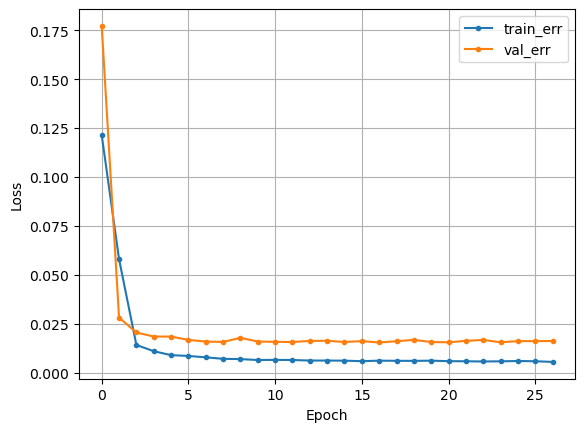

In [96]:
# EarlyStopping 콜백 정의
early_stopping = EarlyStopping(
    monitor='val_loss',   # 검증 손실이 개선되지 않을 때 중단
    patience=10,           # 개선되지 않는 에폭 수
    restore_best_weights=True  # 최적 성능의 가중치 복원
)


model.compile(optimizer=Adam(learning_rate=0.0001), loss='mse', metrics=['mean_squared_error'])
history = model.fit(x_train, y_train_scaled, epochs=50, batch_size=16, validation_data=(x_val, y_val_scaled), callbacks=[early_stopping]).history
dl_history_plot(history)

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 3s/step
RMSE : 3167.0907744682468
MAE : 1963.7634765625
MAPE : 1.1892621231234483e+18
R2 Score : 0.36365814257979345


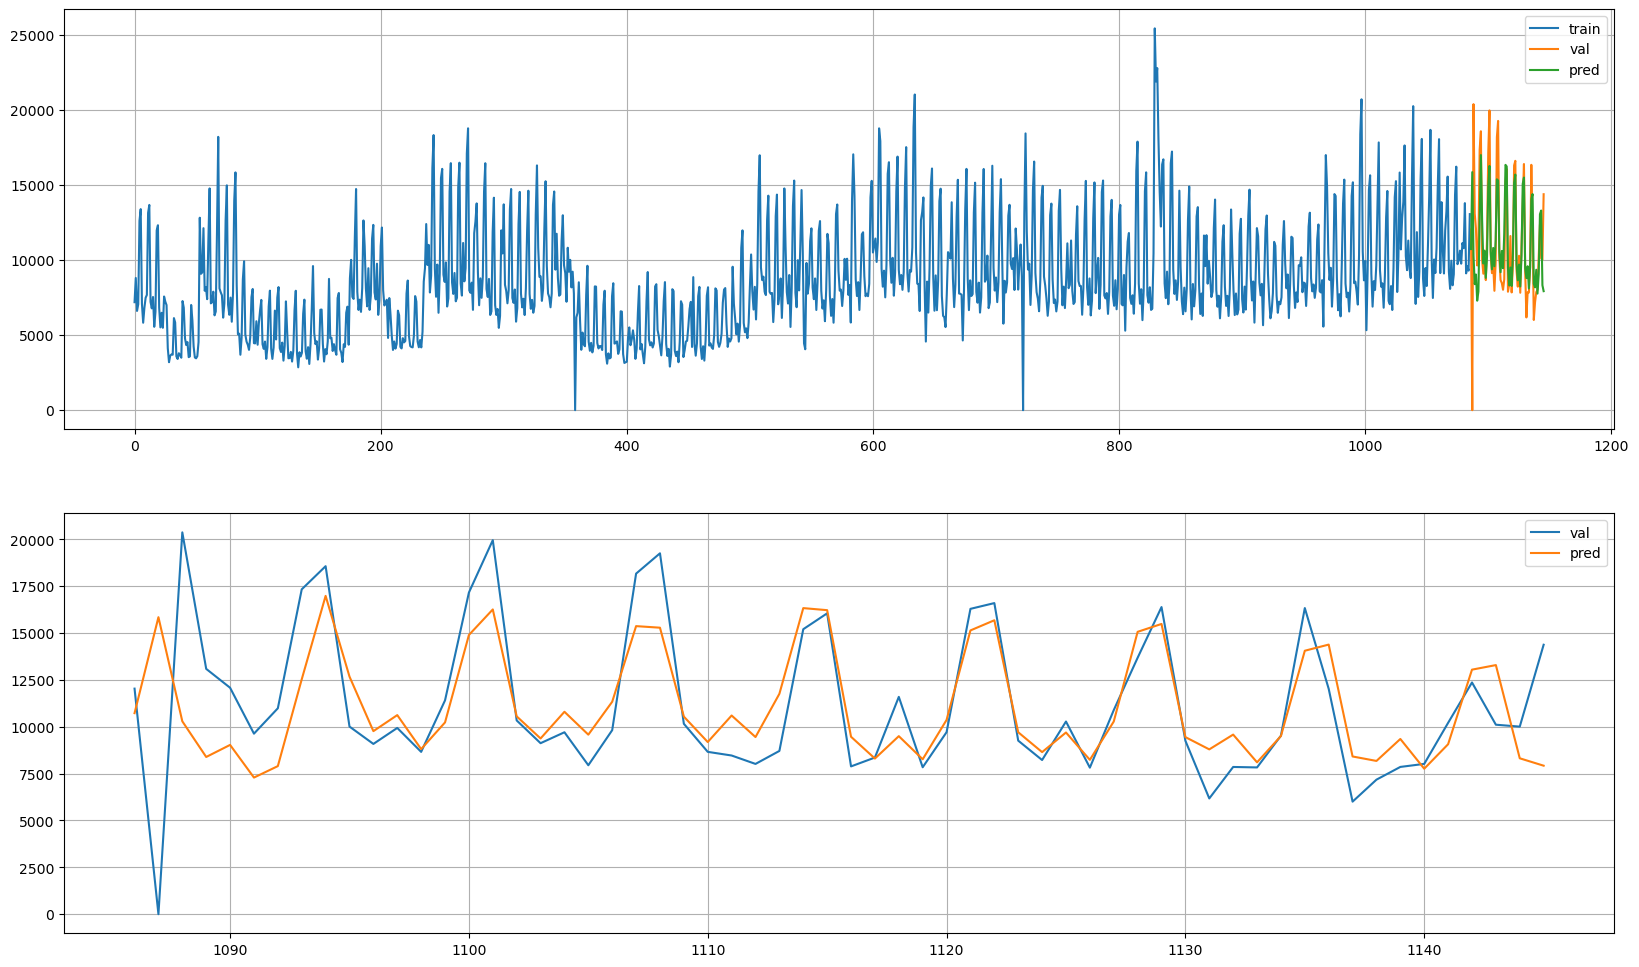

In [97]:
y_pred_1 = model.predict(x_val)
y_pred = sc_y.inverse_transform(y_pred_1)#[:,0].squeeze(1).reshape(-1,1)) #여기 나중에 다시한번 확인 필요

get_metrics(y_val, y_pred)
plot_model_result(y_train, y_val, y_pred)

### **2) 상품 : 12 - Milk**

* **데이터 준비**

In [100]:
x_temporal, y_temporal =temporalize(x2, y2, 7)

x_train, x_val = x_temporal[:-60], x_temporal[-60:]
y_train, y_val = y_temporal[:-60], y_temporal[-60:]

sc = MinMaxScaler()
x_train = sc.fit_transform(x_train.reshape(-1, x_train.shape[-1])).reshape(x_train.shape)
x_val = sc.transform(x_val.reshape(-1, x_val.shape[-1])).reshape(x_val.shape)

sc_y = MinMaxScaler()
y_train_scaled = sc_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = sc_y.transform(y_val.reshape(-1, 1)).ravel()

timesteps = x_train.shape[1]
nfeatures = x_train.shape[2]
x_train.shape, y_train.shape, x_val.shape, y_val.shape

((1084, 7, 18), (1084,), (60, 7, 18), (60,))

* **모델링**

In [102]:
clear_session()
model = Sequential([
    Input(shape=(timesteps, nfeatures)),
    LSTM(50, activation='relu'),
    Dense(1)
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          13,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,851 (54.11 KB)

 Trainable params: 13,851 (54.11 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.0304 - val_loss: 0.0086
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0058 - val_loss: 0.0069
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0045 - val_loss: 0.0070
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0055 - val_loss: 0.0069
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0041 - val_loss: 0.0077
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0044 - val_loss: 0.0068
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0038 - val_loss: 0.0068
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0037 - val_loss: 0.0069
Epoch 9/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0041 - val_loss: 0.0070
Epoch 10/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0033 - val_loss: 0.0070
Epoch 11/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0050 - val_loss: 0.0070
Epoch 12/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.005

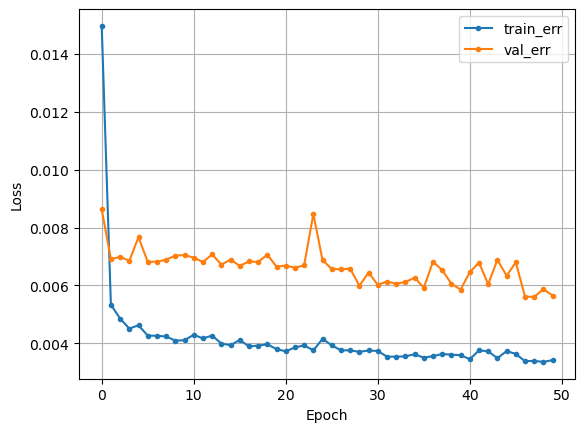

In [103]:
model.compile(optimizer= Adam(), loss='mse')
history = model.fit(x_train, y_train_scaled, epochs=50, batch_size=16, validation_data=(x_val, y_val_scaled)).history
dl_history_plot(history)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 640ms/step
RMSE : 2790.048949627382
MAE : 1591.9504231770834
MAPE : 1.2135864722631862e+18
R2 Score : 0.3665481490866487


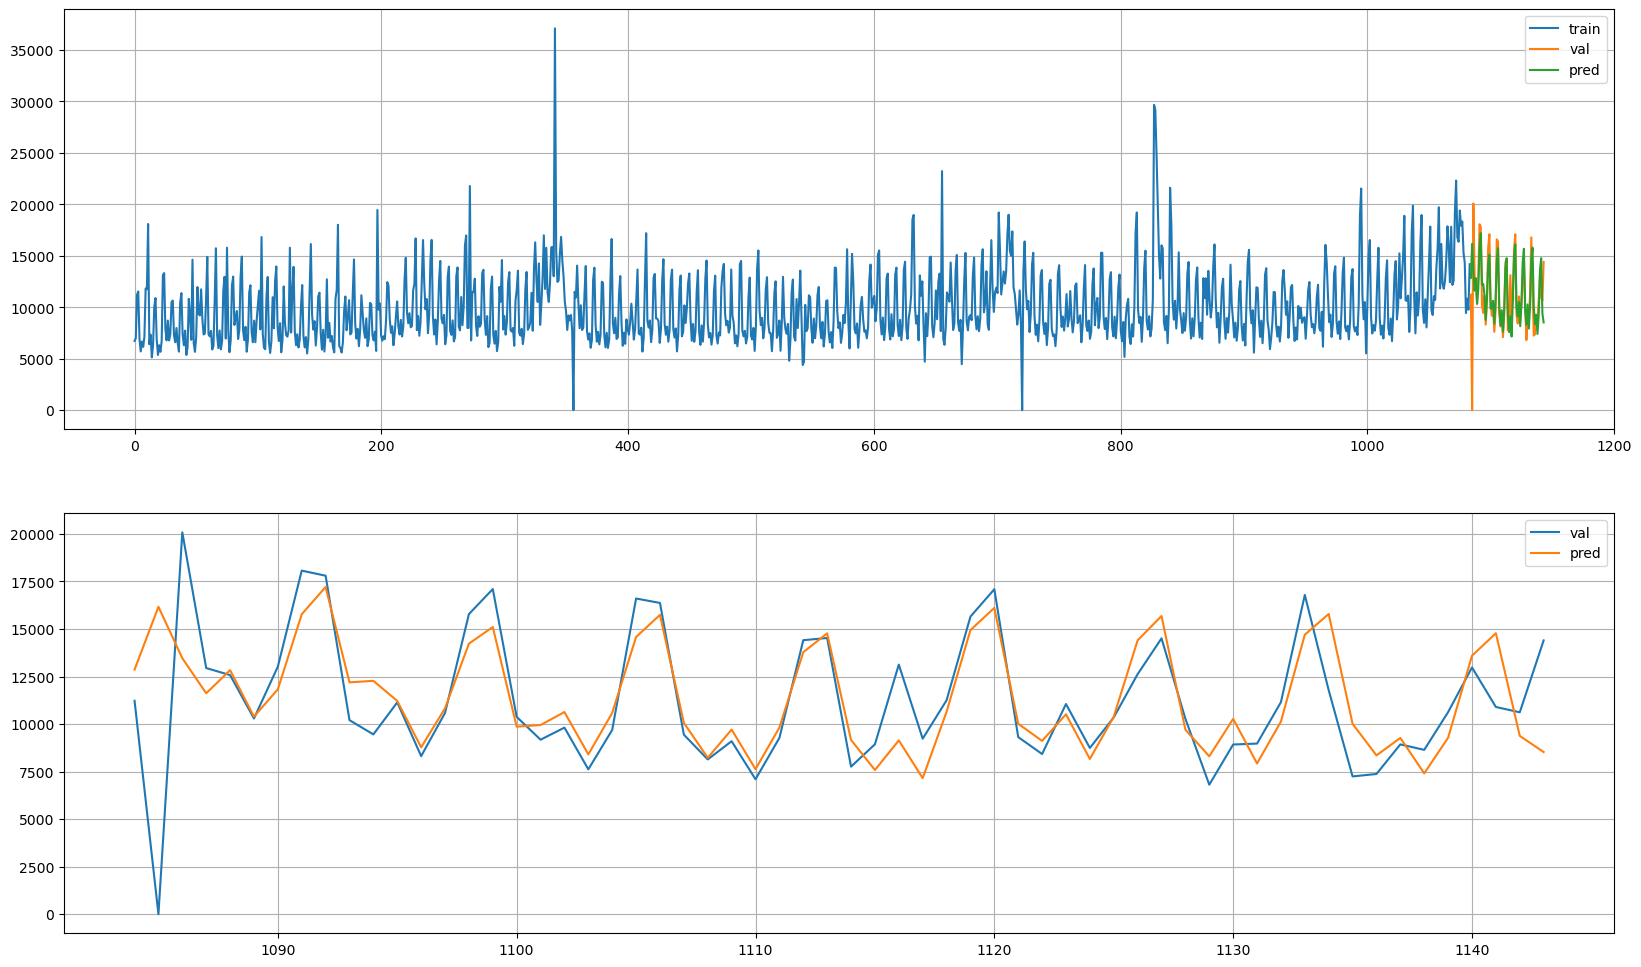

In [104]:
y_pred_1 = model.predict(x_val)
y_pred = sc_y.inverse_transform(y_pred_1)#[:,0].squeeze(1).reshape(-1,1))

get_metrics(y_val, y_pred)
plot_model_result(y_train, y_val, y_pred)

### **3) 상품 : 42 - Agricultural products**

* **데이터 준비**

In [107]:
x_temporal, y_temporal =temporalize(x3, y3, 7)

x_train, x_val = x_temporal[:-60], x_temporal[-60:]
y_train, y_val = y_temporal[:-60], y_temporal[-60:]

sc = MinMaxScaler()
x_train = sc.fit_transform(x_train.reshape(-1, x_train.shape[-1])).reshape(x_train.shape)
x_val = sc.transform(x_val.reshape(-1, x_val.shape[-1])).reshape(x_val.shape)

sc_y = MinMaxScaler()
y_train_scaled = sc_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = sc_y.transform(y_val.reshape(-1, 1)).ravel()

timesteps = x_train.shape[1]
nfeatures = x_train.shape[2]
x_train.shape, y_train.shape, x_val.shape, y_val.shape

((1087, 7, 18), (1087,), (60, 7, 18), (60,))

* **모델링**

In [109]:
clear_session()
model = Sequential([
    Input(shape=(timesteps, nfeatures)),
    LSTM(128, return_sequences=True, activation='relu'),
    LSTM(64, activation='relu'),
    Dense(1)
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 7, 128)              │          75,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 124,737 (487.25 KB)

 Trainable params: 124,737 (487.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - loss: 0.0819 - val_loss: 0.0103
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0137 - val_loss: 0.0068
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0096 - val_loss: 0.0060
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0097 - val_loss: 0.0058
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0072 - val_loss: 0.0071
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0081 - val_loss: 0.0054
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0071 - val_loss: 0.0067
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0068 - val_loss: 0.0053
Epoch 9/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0068 - val_loss: 0.0062
Epoch 10/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0065 - val_loss: 0.0065
Epoch 11/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0071 - val_loss: 0.0074
Epoch 12/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.

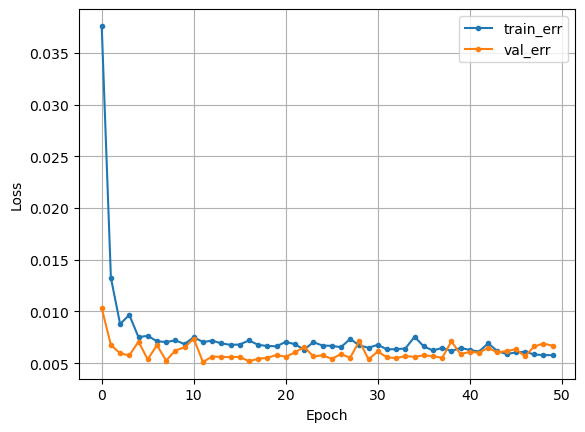

In [110]:
model.compile(optimizer= Adam(), loss='mse')
history = model.fit(x_train, y_train_scaled, epochs=50, batch_size=16, validation_data=(x_val, y_val_scaled)).history
dl_history_plot(history)

1/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001A2D7A6B560> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step
RMSE : 12.345126205116925
MAE : 9.743282826741536
MAPE : 0.11190285401937806
R2 Score : 0.337390798343316


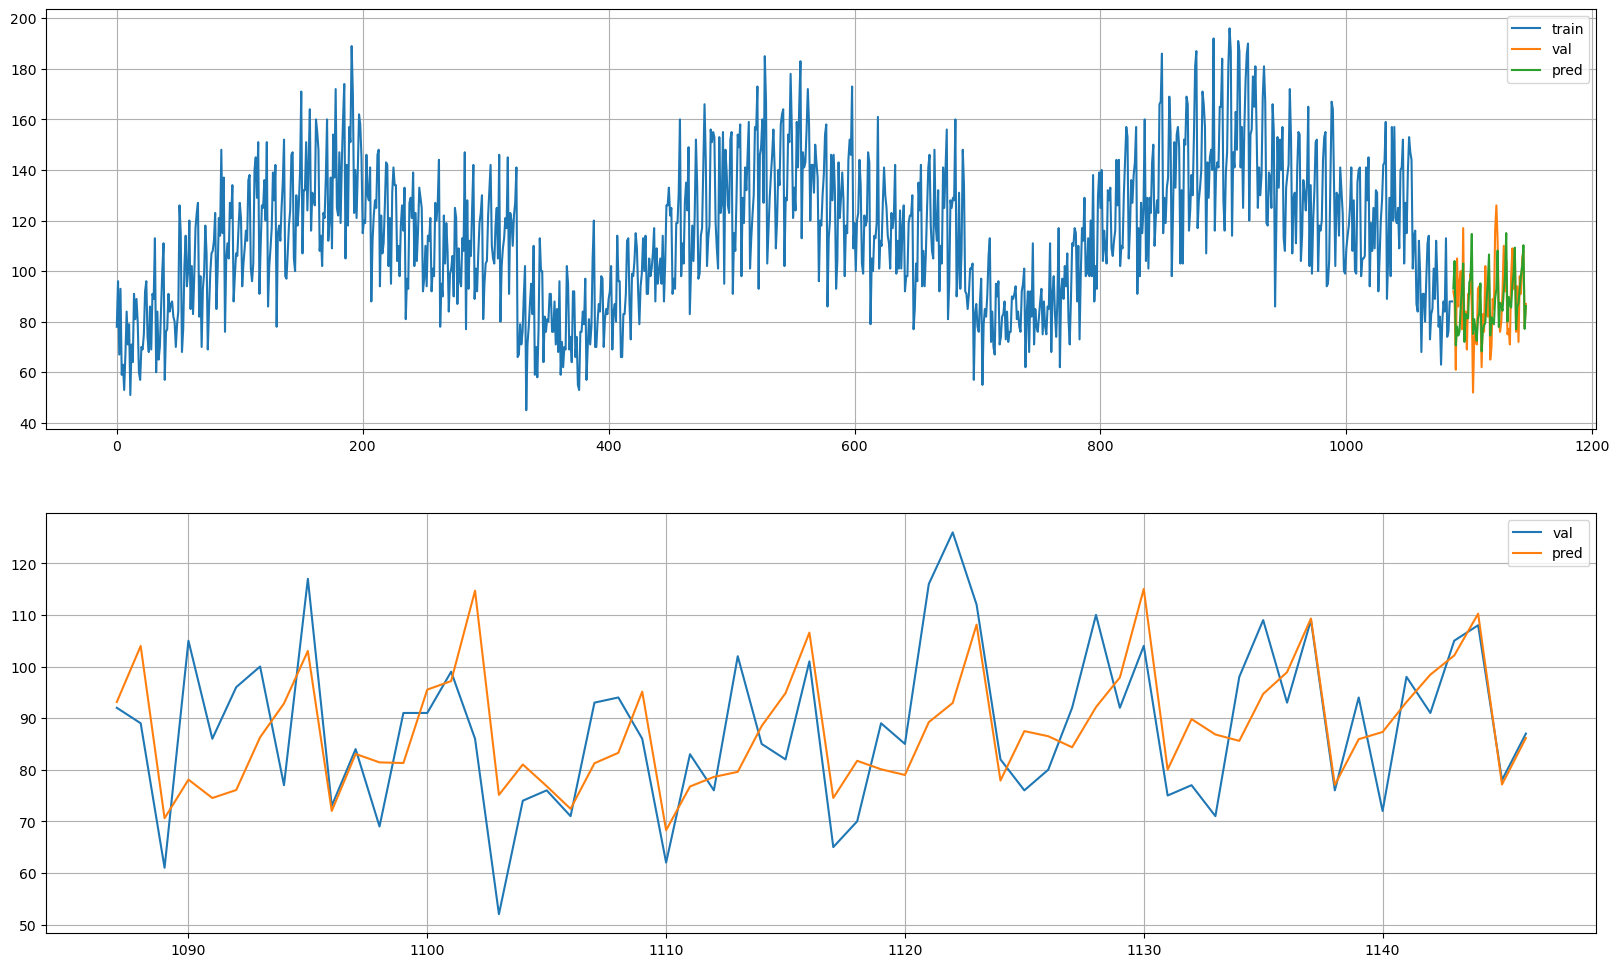

In [111]:
y_pred_1 = model.predict(x_val)
y_pred = sc_y.inverse_transform(y_pred_1.reshape(-1, 1)).ravel()

get_metrics(y_val, y_pred)
plot_model_result(y_train, y_val, y_pred)

## **(2) CNN 초기 모델링**

### **1) 상품 : 3 - Beverage**

* **데이터 준비**

In [116]:
x_temporal, y_temporal =temporalize(x1, y1, 7)

x_train, x_val = x_temporal[:-60], x_temporal[-60:]
y_train, y_val = y_temporal[:-60], y_temporal[-60:]

sc = MinMaxScaler()
x_train = sc.fit_transform(x_train.reshape(-1, x_train.shape[-1])).reshape(x_train.shape)
x_val = sc.transform(x_val.reshape(-1, x_val.shape[-1])).reshape(x_val.shape)

sc_y = MinMaxScaler()
y_train_scaled = sc_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = sc_y.transform(y_val.reshape(-1, 1)).ravel()

timesteps = x_train.shape[1]
nfeatures = x_train.shape[2]
x_train.shape, y_train.shape, x_val.shape, y_val.shape

((1084, 7, 16), (1084,), (60, 7, 16), (60,))

* **모델링**

In [118]:
from tensorflow.keras.layers import Conv2D, GlobalAveragePooling2D, Reshape, Dropout, Dense, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.backend import clear_session
 
# 기존 세션 초기화
clear_session()
 
# Conv2D로 변환된 모델
model = Sequential([
    # Conv2D에 맞게 데이터 차원 추가
    Reshape((timesteps, nfeatures, 1), input_shape=(timesteps, nfeatures)),  # 채널 차원 추가
    Conv2D(filters=32, kernel_size=(5, 5), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(filters=64, kernel_size=(5, 5), activation='relu', padding='same'),
    Dropout(0.3),
    GlobalAveragePooling2D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1)
])
 
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ reshape (Reshape)                    │ (None, 7, 16, 1)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 7, 16, 32)           │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 7, 16, 32)           │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 7, 16, 64)           │          51,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 7, 16, 64)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 56,449 (220.50 KB)

 Trainable params: 56,385 (220.25 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.1142 - val_loss: 0.1718
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0163 - val_loss: 0.1563
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0142 - val_loss: 0.1443
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0101 - val_loss: 0.1234
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0110 - val_loss: 0.1034
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0111 - val_loss: 0.0852
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0103 - val_loss: 0.0615
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0107 - val_loss: 0.0429
Epoch 9/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0090 - val_loss: 0.0269
Epoch 10/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0105 - val_loss: 0.0225
Epoch 11/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0100 - val_loss: 0.0151
Epoch 12/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.

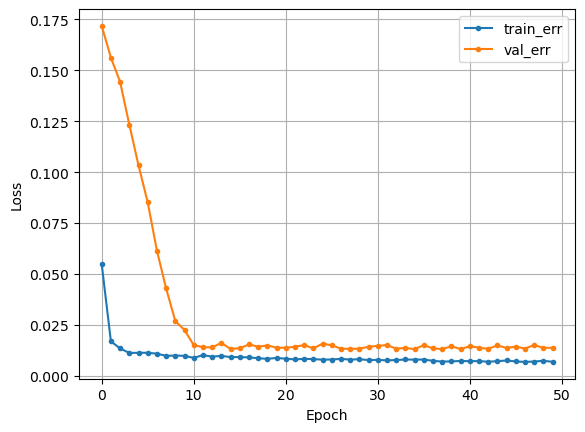

In [119]:
model.compile(optimizer= Adam(learning_rate=0.0001), loss='mse')
history = model.fit(x_train, y_train_scaled, epochs=50, batch_size=16, validation_data=(x_val, y_val_scaled)).history
dl_history_plot(history)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 385ms/step
RMSE : 2985.2180596890366
MAE : 1865.7543863932292
MAPE : 9.023816540475447e+17
R2 Score : 0.43464454168056565


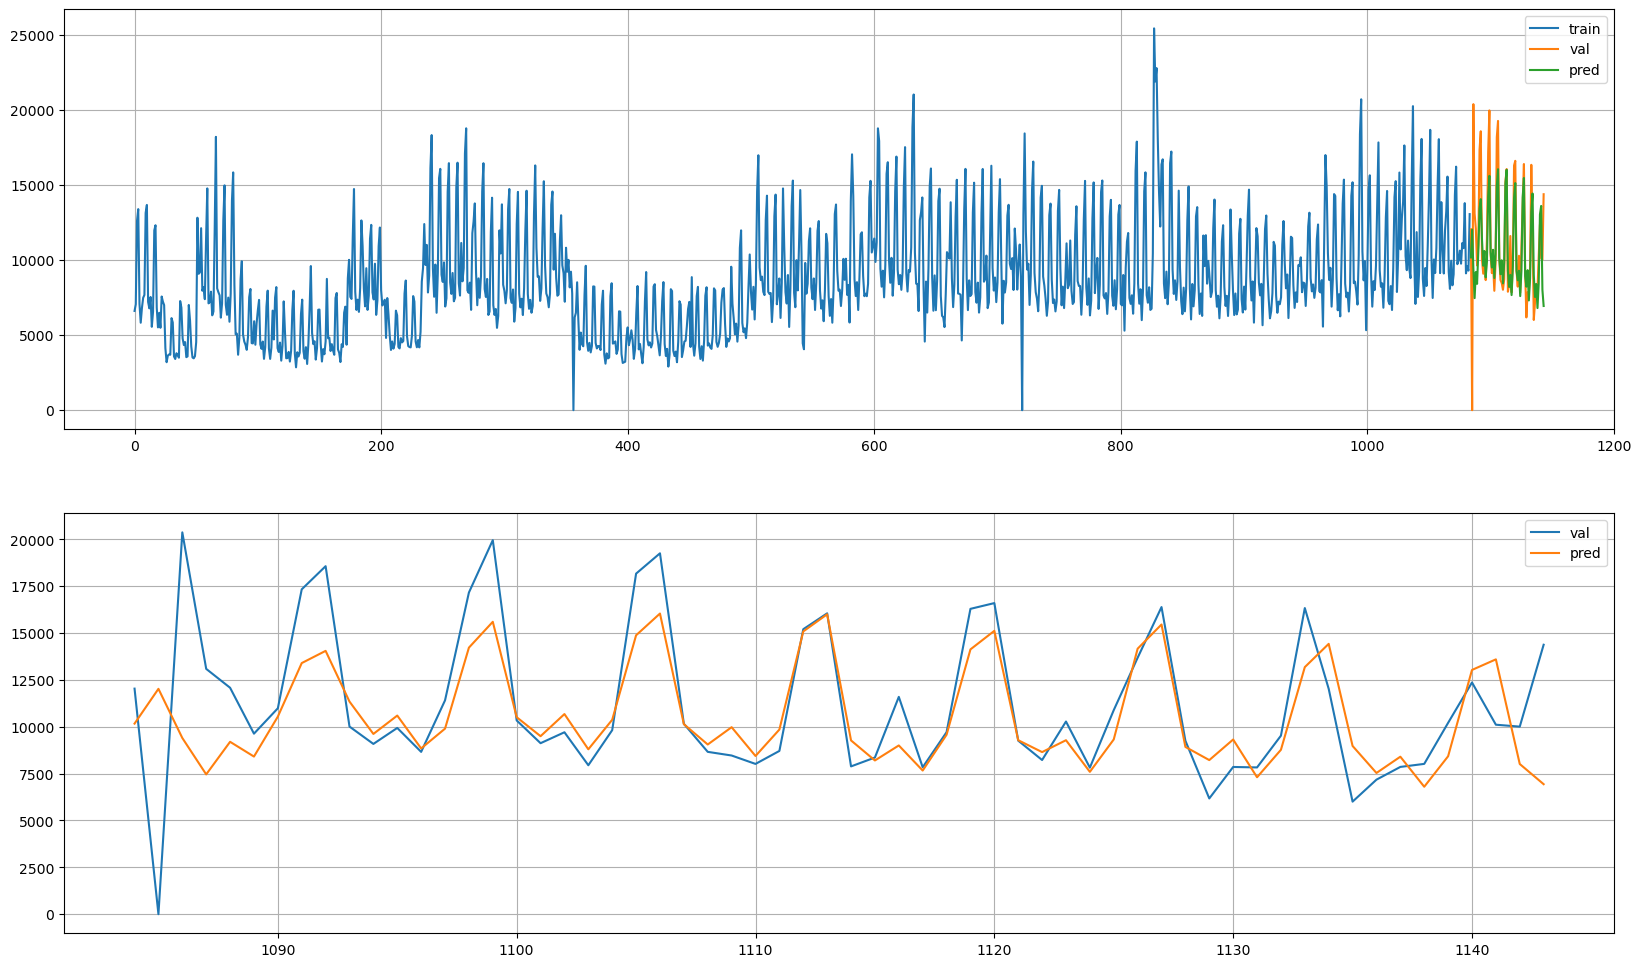

In [120]:
y_pred_1 = model.predict(x_val)
y_pred = sc_y.inverse_transform(y_pred_1)

get_metrics(y_val, y_pred)
plot_model_result(y_train, y_val, y_pred)

### **2) 상품 : 12 - Milk**

* **데이터 준비**

In [127]:
x_temporal, y_temporal =temporalize(x2, y2, 7)

x_train, x_val = x_temporal[:-60], x_temporal[-60:]
y_train, y_val = y_temporal[:-60], y_temporal[-60:]

sc = MinMaxScaler()
x_train = sc.fit_transform(x_train.reshape(-1, x_train.shape[-1])).reshape(x_train.shape)
x_val = sc.transform(x_val.reshape(-1, x_val.shape[-1])).reshape(x_val.shape)

sc_y = MinMaxScaler()
y_train_scaled = sc_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = sc_y.transform(y_val.reshape(-1, 1)).ravel()

timesteps = x_train.shape[1]
nfeatures = x_train.shape[2]
x_train.shape, y_train.shape, x_val.shape, y_val.shape

((1084, 7, 18), (1084,), (60, 7, 18), (60,))

In [128]:
from tensorflow.keras.layers import Conv2D, GlobalAveragePooling2D, Reshape, Dropout, Dense, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.backend import clear_session
 
# 기존 세션 초기화
clear_session()
 
# Conv2D로 변환된 모델
model = Sequential([
    # Conv2D에 맞게 데이터 차원 추가
    Reshape((timesteps, nfeatures, 1), input_shape=(timesteps, nfeatures)),  # 채널 차원 추가
    Conv2D(filters=32, kernel_size=(5, 5), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(filters=64, kernel_size=(5, 5), activation='relu', padding='same'),
    Dropout(0.3),
    GlobalAveragePooling2D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1)
])
 
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ reshape (Reshape)                    │ (None, 7, 18, 1)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 7, 18, 32)           │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 7, 18, 32)           │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 7, 18, 64)           │          51,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 7, 18, 64)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 56,449 (220.50 KB)

 Trainable params: 56,385 (220.25 KB)

 Non-trainable params: 64 (256.00 B)

* **모델링**

Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 0.0396 - val_loss: 0.0781
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0157 - val_loss: 0.0753
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0118 - val_loss: 0.0710
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0086 - val_loss: 0.0611
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0078 - val_loss: 0.0508
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0073 - val_loss: 0.0382
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0080 - val_loss: 0.0257
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0062 - val_loss: 0.0169
Epoch 9/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0068 - val_loss: 0.0119
Epoch 10/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0064 - val_loss: 0.0084
Epoch 11/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0057 - val_loss: 0.0072
Epoch 12/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.

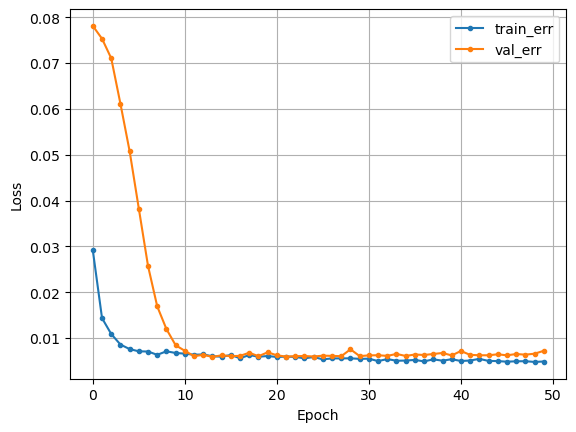

In [130]:
model.compile(optimizer= Adam(learning_rate=0.0001), loss='mse')
history = model.fit(x_train, y_train_scaled, epochs=50, batch_size=16, validation_data=(x_val, y_val_scaled)).history
dl_history_plot(history)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 356ms/step
RMSE : 3149.6756472908833
MAE : 2153.7533447265623
MAPE : 1.2309374254564682e+18
R2 Score : 0.19272476617482048


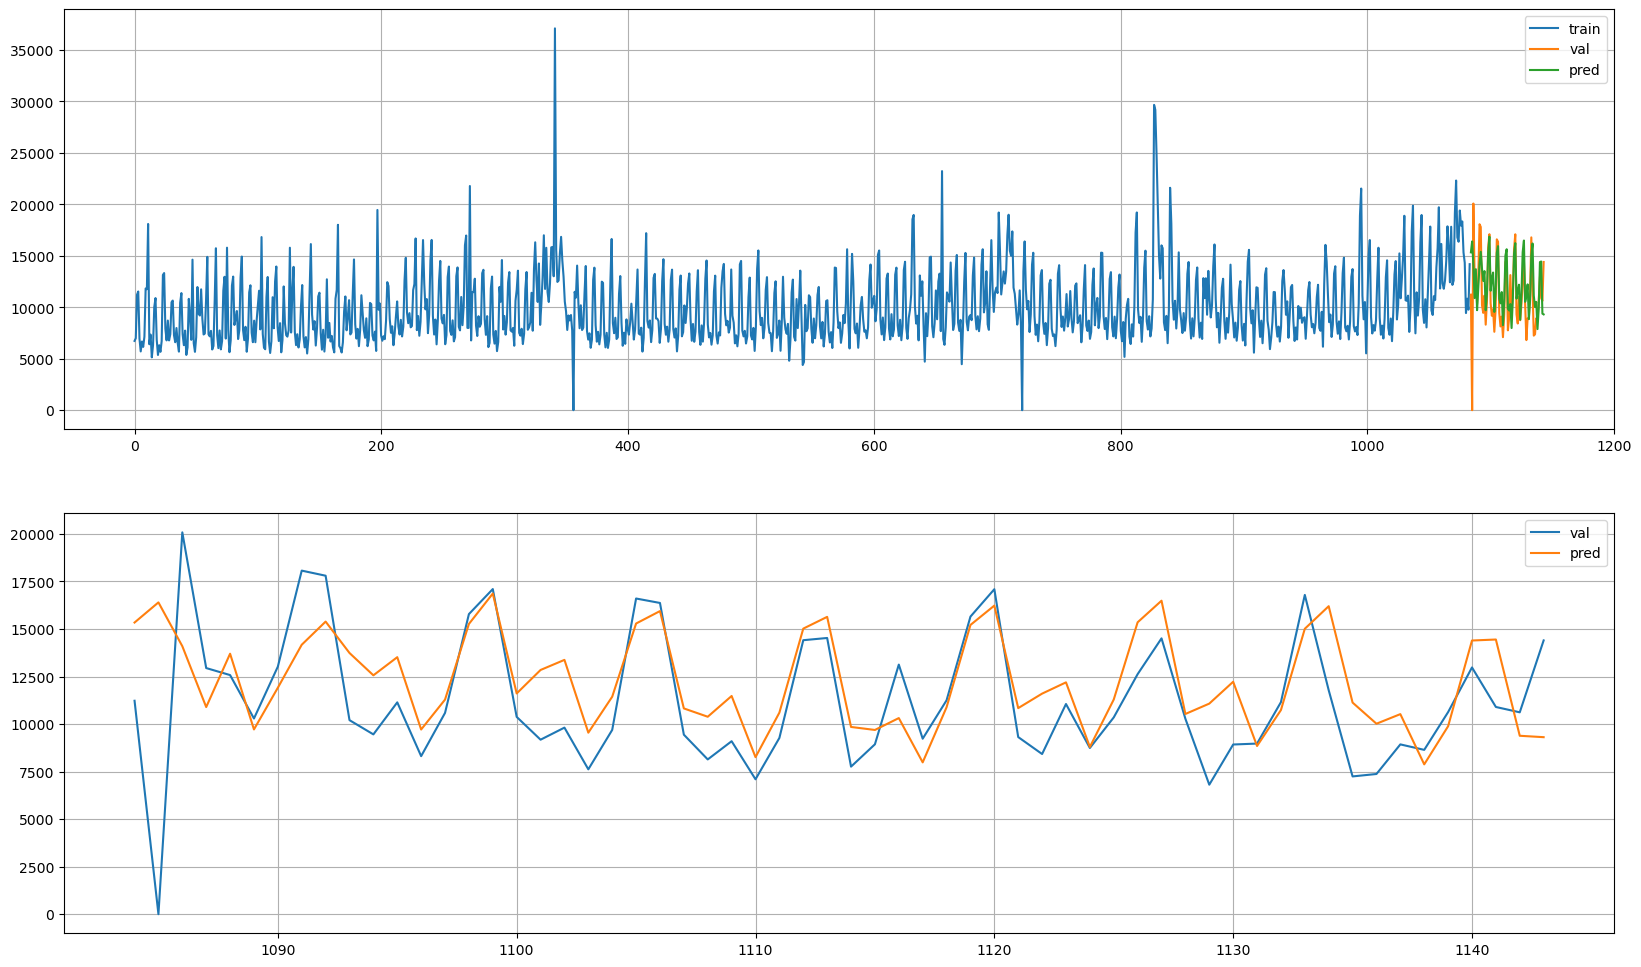

In [131]:
y_pred_1 = model.predict(x_val)
y_pred = sc_y.inverse_transform(y_pred_1)

get_metrics(y_val, y_pred)
plot_model_result(y_train, y_val, y_pred)

### **1) 상품 : 3 - Agricultural products**

* **데이터 준비**

In [135]:
x_temporal, y_temporal =temporalize(x3, y3, 7)

x_train, x_val = x_temporal[:-60], x_temporal[-60:]
y_train, y_val = y_temporal[:-60], y_temporal[-60:]

sc = MinMaxScaler()
x_train = sc.fit_transform(x_train.reshape(-1, x_train.shape[-1])).reshape(x_train.shape)
x_val = sc.transform(x_val.reshape(-1, x_val.shape[-1])).reshape(x_val.shape)

sc_y = MinMaxScaler()
y_train_scaled = sc_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = sc_y.transform(y_val.reshape(-1, 1)).ravel()

timesteps = x_train.shape[1]
nfeatures = x_train.shape[2]
x_train.shape, y_train.shape, x_val.shape, y_val.shape

((1087, 7, 18), (1087,), (60, 7, 18), (60,))

* **모델링**

In [138]:
from tensorflow.keras.layers import Conv2D, GlobalAveragePooling2D, Reshape, Dropout, Dense, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.backend import clear_session
 
# 기존 세션 초기화
clear_session()
 
# Conv2D로 변환된 모델
model = Sequential([
    # Conv2D에 맞게 데이터 차원 추가
    Reshape((timesteps, nfeatures, 1), input_shape=(timesteps, nfeatures)),  # 채널 차원 추가
    Conv2D(filters=32, kernel_size=(5, 5), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(filters=64, kernel_size=(5, 5), activation='relu', padding='same'),
    Dropout(0.3),
    GlobalAveragePooling2D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1)
])
 
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ reshape (Reshape)                    │ (None, 7, 18, 1)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 7, 18, 32)           │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 7, 18, 32)           │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 7, 18, 64)           │          51,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 7, 18, 64)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 56,449 (220.50 KB)

 Trainable params: 56,385 (220.25 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - loss: 0.2444 - val_loss: 0.0524
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0366 - val_loss: 0.0497
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0249 - val_loss: 0.0473
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0209 - val_loss: 0.0407
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0195 - val_loss: 0.0350
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0173 - val_loss: 0.0243
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0155 - val_loss: 0.0153
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0172 - val_loss: 0.0107
Epoch 9/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0167 - val_loss: 0.0079
Epoch 10/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0149 - val_loss: 0.0069
Epoch 11/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0156 - val_loss: 0.0052
Epoch 12/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.

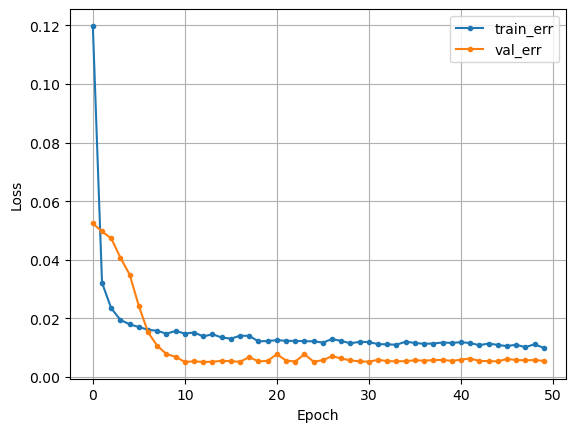

In [139]:
model.compile(optimizer= Adam(learning_rate=0.0001), loss='mse')
history = model.fit(x_train, y_train_scaled, epochs=50, batch_size=16, validation_data=(x_val, y_val_scaled)).history
dl_history_plot(history)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step
RMSE : 11.219299090154754
MAE : 8.777444839477539
MAPE : 0.10157842813859899
R2 Score : 0.452734783151854


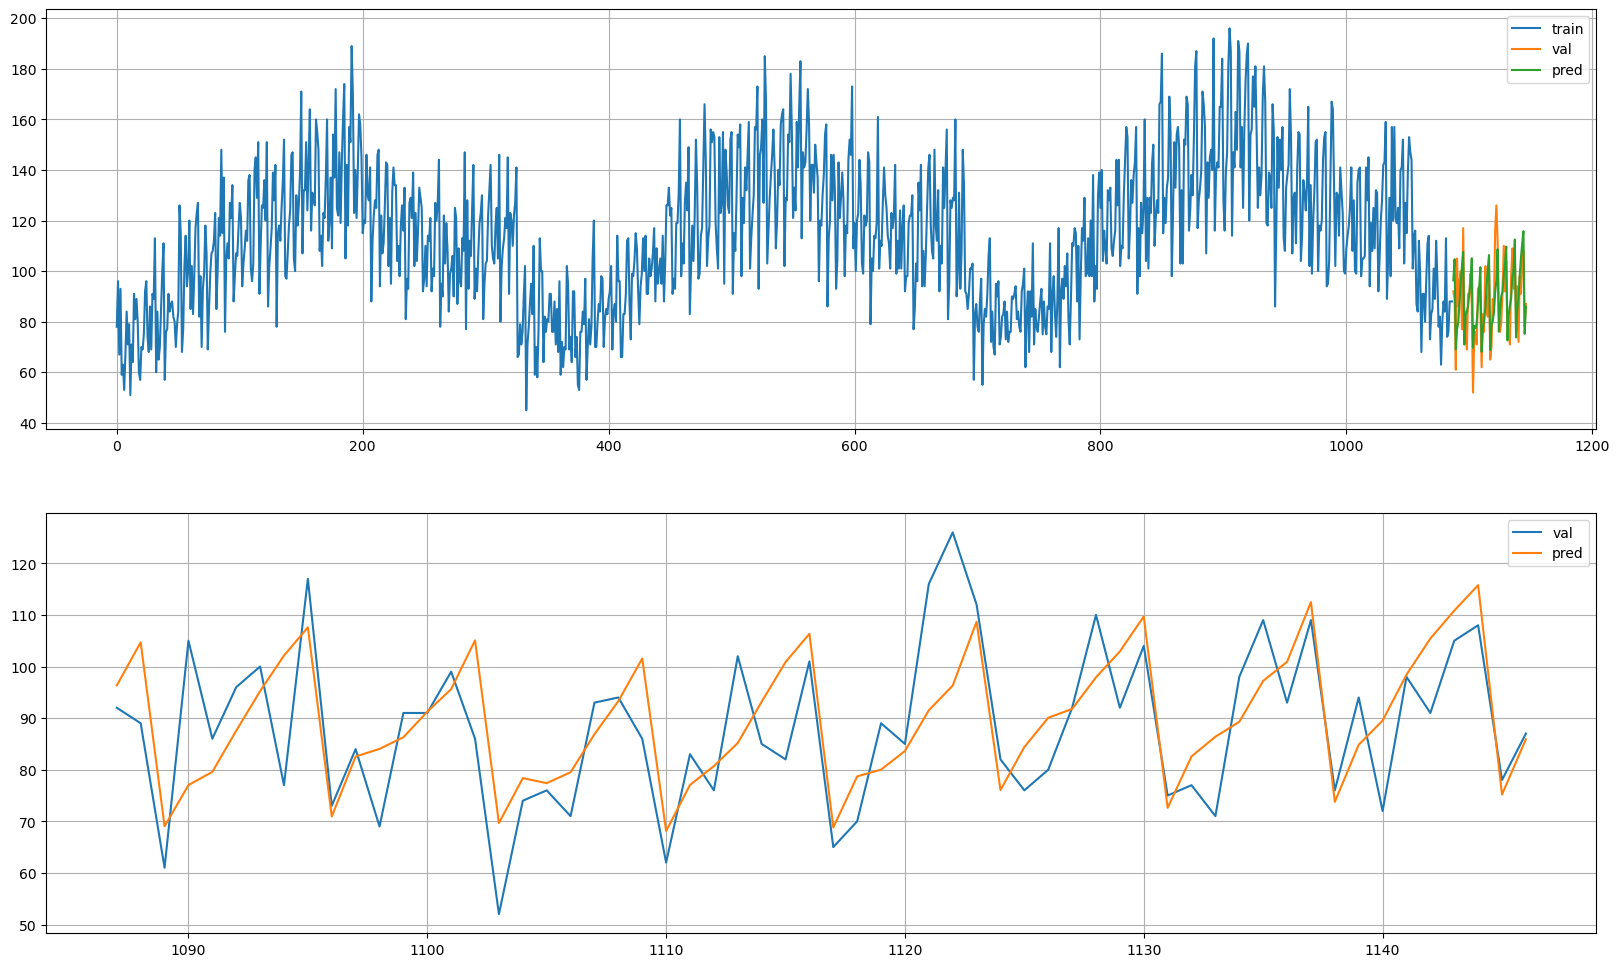

In [140]:
y_pred_1 = model.predict(x_val)
y_pred = sc_y.inverse_transform(y_pred_1)

get_metrics(y_val, y_pred)
plot_model_result(y_train, y_val, y_pred)

# **5.데이터 저장**

* **세부 요구사항**
    * 상품코드별 데이터셋을 저장하시오.
    * joblib.dump를 이용하시오.
    * 저장할 파일의 확장자는 보통 .pkl 입니다.

In [71]:
columns_list = list(x1.columns)
print(columns_list)


['Qty', 'Num_Customer', 'diff_step1', 'shift_step1', 'diff_step7', 'shift_step7', 'diff_step15', 'shift_step15', 'diff_step30', 'shift_step30', 'Max Temp', 'Min Temp', 'Precipitation (inches)', 'accum30.Prec.', 'accum60.Prec.', 'accum90.Prec.', 'accum120.Prec.', 'Wine', 'WTI_Price', 'dow_Mon', 'dow_Sat', 'dow_Sun', 'dow_Thu', 'dow_Tue', 'dow_Wed']


In [73]:
# 필요한 컬럼만 남기고 나머지 드랍하기
x1 = x1[['Qty', 'Num_Customer', 'diff_step1', 'shift_step1', 'diff_step7', 'shift_step7', 'diff_step15', 'shift_step15', 'diff_step30', 'WTI_Price', 'dow_Mon', 'dow_Sat', 'dow_Sun', 'dow_Thu', 'dow_Tue', 'dow_Wed']]


In [75]:
print(x1)

                Qty  Num_Customer  diff_step1  shift_step1  diff_step7  \
Date                                                                     
2014-01-01      0.0          4422         0.0          0.0         0.0   
2014-01-02   9853.0          4422      9853.0          0.0         0.0   
2014-01-03   8647.0          4167     -1206.0       9853.0         0.0   
2014-01-04  15153.0          5341      6506.0       8647.0         0.0   
2014-01-05  15606.0          5123       453.0      15153.0         0.0   
...             ...           ...         ...          ...         ...   
2017-02-22   7856.0          3834       679.0       7177.0         2.0   
2017-02-23   8018.0          3955       162.0       7856.0       189.0   
2017-02-24  10208.0          4549      2190.0       8018.0       684.0   
2017-02-25  12361.0          4619      2153.0      10208.0     -3970.0   
2017-02-26  10108.0          3877     -2253.0      12361.0     -1915.0   

            shift_step7  diff_step15 

In [77]:
x2=x2[['Qty', 'Num_Customer', 'Frozen','Prepared', 'Yogurt', 'diff_step1', 'shift_step1', 'diff_step7', 'shift_step7', 'diff_step15', 'diff_step30', 'WTI_Price', 'dow_Mon', 'dow_Sat', 'dow_Sun', 'dow_Thu', 'dow_Tue', 'dow_Wed']]

In [79]:
print(x2)

                Qty  Num_Customer  Frozen  Prepared   Yogurt  diff_step1  \
Date                                                                       
2014-01-01      0.0          4422     0.0     0.000      0.0         0.0   
2014-01-02   9647.0          4422  2991.0  1302.470   9647.0      9647.0   
2014-01-03   8879.0          4167  2694.0  1243.054   8879.0      -768.0   
2014-01-04  14188.0          5341  4355.0  1882.780  14188.0      5309.0   
2014-01-05  14490.0          5123  4228.0  2029.317  14490.0       302.0   
...             ...           ...     ...       ...      ...         ...   
2017-02-22   8931.0          3834  2206.0  1389.665   8931.0      1557.0   
2017-02-23   8643.0          3955  2099.0  1400.192   8643.0      -288.0   
2017-02-24  10630.0          4549  2530.0  1743.020  10630.0      1987.0   
2017-02-25  12978.0          4619  3341.0  2006.152  12978.0      2348.0   
2017-02-26  10899.0          3877  2777.0  1699.694  10899.0     -2079.0   

           

In [84]:
x3=x3[['Qty', 'diff_step1', 'shift_step1', 'diff_step7', 'shift_step7', 'diff_step15', 'shift_step15', 'diff_step30', 'shift_step30', 'Max Temp', 'Min Temp', 'accum90.Prec.', 'dow_Mon', 'dow_Sat', 'dow_Sun', 'dow_Thu', 'dow_Tue', 'dow_Wed']]

In [86]:
print(x3)

              Qty  diff_step1  shift_step1  diff_step7  shift_step7  \
Date                                                                  
2014-01-01   51.0         0.0          0.0         0.0          0.0   
2014-01-02   76.0        25.0         51.0         0.0          0.0   
2014-01-03   74.0        -2.0         76.0         0.0          0.0   
2014-01-04   78.0         4.0         74.0         0.0          0.0   
2014-01-05   88.0        10.0         78.0         0.0          0.0   
...           ...         ...          ...         ...          ...   
2017-02-22   72.0       -22.0         94.0         1.0         71.0   
2017-02-23   98.0        26.0         72.0         0.0         98.0   
2017-02-24   91.0        -7.0         98.0       -18.0        109.0   
2017-02-25  105.0        14.0         91.0        12.0         93.0   
2017-02-26  108.0         3.0        105.0        -1.0        109.0   

            diff_step15  shift_step15  diff_step30  shift_step30  Max Temp  